# Statistics for Michel electron candidate

### Created by Shu, 202508---

<br />
<br />
<br />
<br />
<br />
<br />

## WVF Coincidence Explore:

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

import os



# ------------------------------------------------------------
# 1️⃣ Define data groups
# ------------------------------------------------------------
data_groups = [

    {
        "data_dir": "./statResult_pds",
        "dates": ["20251101", "20251102"
                  ]
    }
]

coinNum = []
coinTrueE = []
coinPDG = []


# ------------------------------------------------------------
# 2️⃣ Read all groups — waveform coincidence counts
# ------------------------------------------------------------
print("\n=== Reading waveform coincidence counts ===")

for group in data_groups:
    data_dir = group["data_dir"]

    print(f"\n[GROUP] {data_dir}")

    for d in group["dates"]:
        fname = f"{data_dir}/print_wvfCoin_count{d}.txt"
        if not os.path.exists(fname):
            print(f"[WARN] Missing {fname}")
            continue

        count = 0
        with open(fname, "r") as file:
            for line in file:
                line = line.strip()
                if not line:
                    continue

                parts = line.split(":")
                if len(parts) >= 2:
                    try:
                        coinNum.append(int(parts[1].strip()))
                        count += 1
                    except ValueError:
                        print(f"[WARN] Could not parse '{parts[1].strip()}' in {fname}")

        print(f"  - Loaded {count:5d} entries from {d} → {os.path.basename(fname)}")


# ------------------------------------------------------------
# 3️⃣ Read all groups — candidate energies
# ------------------------------------------------------------
print("\n=== Reading candidate energies ===")

for group in data_groups:
    data_dir = group["data_dir"]

    print(f"\n[GROUP] {data_dir}")

    for d in group["dates"]:
        fname = f"{data_dir}/print_trueE{d}.txt"
        if not os.path.exists(fname):
            print(f"[WARN] Missing {fname}")
            continue

        count = 0
        with open(fname, "r") as file:
            for line in file:
                value = line.strip()
                if value:
                    try:
                        coinTrueE.append(float(value))
                        count += 1
                    except ValueError:
                        print(f"[WARN] Could not convert '{value}' in {fname} to float.")

        print(f"  - Loaded {count:5d} entries from {d} → {os.path.basename(fname)}")


# ------------------------------------------------------------
# 4️⃣ Read all groups — PDG codes
# ------------------------------------------------------------
print("\n=== Reading PDG codes ===")

for group in data_groups:
    data_dir = group["data_dir"]

    print(f"\n[GROUP] {data_dir}")

    for d in group["dates"]:
        fname = f"{data_dir}/print_truePDG{d}.txt"
        if not os.path.exists(fname):
            print(f"[WARN] Missing {fname}")
            continue

        count = 0
        with open(fname, "r") as file:
            for line in file:
                value = line.strip()
                if value:
                    try:
                        coinPDG.append(int(value))
                        count += 1
                    except ValueError:
                        print(f"[WARN] Could not convert '{value}' in {fname} to int.")

        print(f"  - Loaded {count:5d} entries from {d} → {os.path.basename(fname)}")





# ------------------------------------------------------------
# ✅ Summary
# ------------------------------------------------------------


print("Event candidates (TPC cut)  : ")
print("Track candidates with NO wvf: ")
print("Number of track candidates  :", len(coinNum))

#coinNum.extend([0] * 44777)



print("\nLength of track coinTrueE: ", len(coinTrueE))
print("Length of track coinPDG  : ", len(coinPDG))





=== Reading waveform coincidence counts ===

[GROUP] ./statResult_pds
  - Loaded   718 entries from 20251101 → print_wvfCoin_count20251101.txt
  - Loaded  1667 entries from 20251102 → print_wvfCoin_count20251102.txt

=== Reading candidate energies ===

[GROUP] ./statResult_pds
  - Loaded   718 entries from 20251101 → print_trueE20251101.txt
  - Loaded  1667 entries from 20251102 → print_trueE20251102.txt

=== Reading PDG codes ===

[GROUP] ./statResult_pds
  - Loaded   718 entries from 20251101 → print_truePDG20251101.txt
  - Loaded  1667 entries from 20251102 → print_truePDG20251102.txt
Event candidates (TPC cut)  : 
Track candidates with NO wvf: 
Number of track candidates  : 2385

Length of track coinTrueE:  2385
Length of track coinPDG  :  2385


Purity of coinNum:  1847 / 2385 (77.44%)
Michel e:  322 / 1847 (17.43%)
Michel p:  1525 / 1847 (82.57%)

Candidates with #opWvf>=4:  2019 / 2385 (84.65%)
Purity:  1534 / 2019 (75.98%)

Values here are based on MS>0.2 & MH>2...


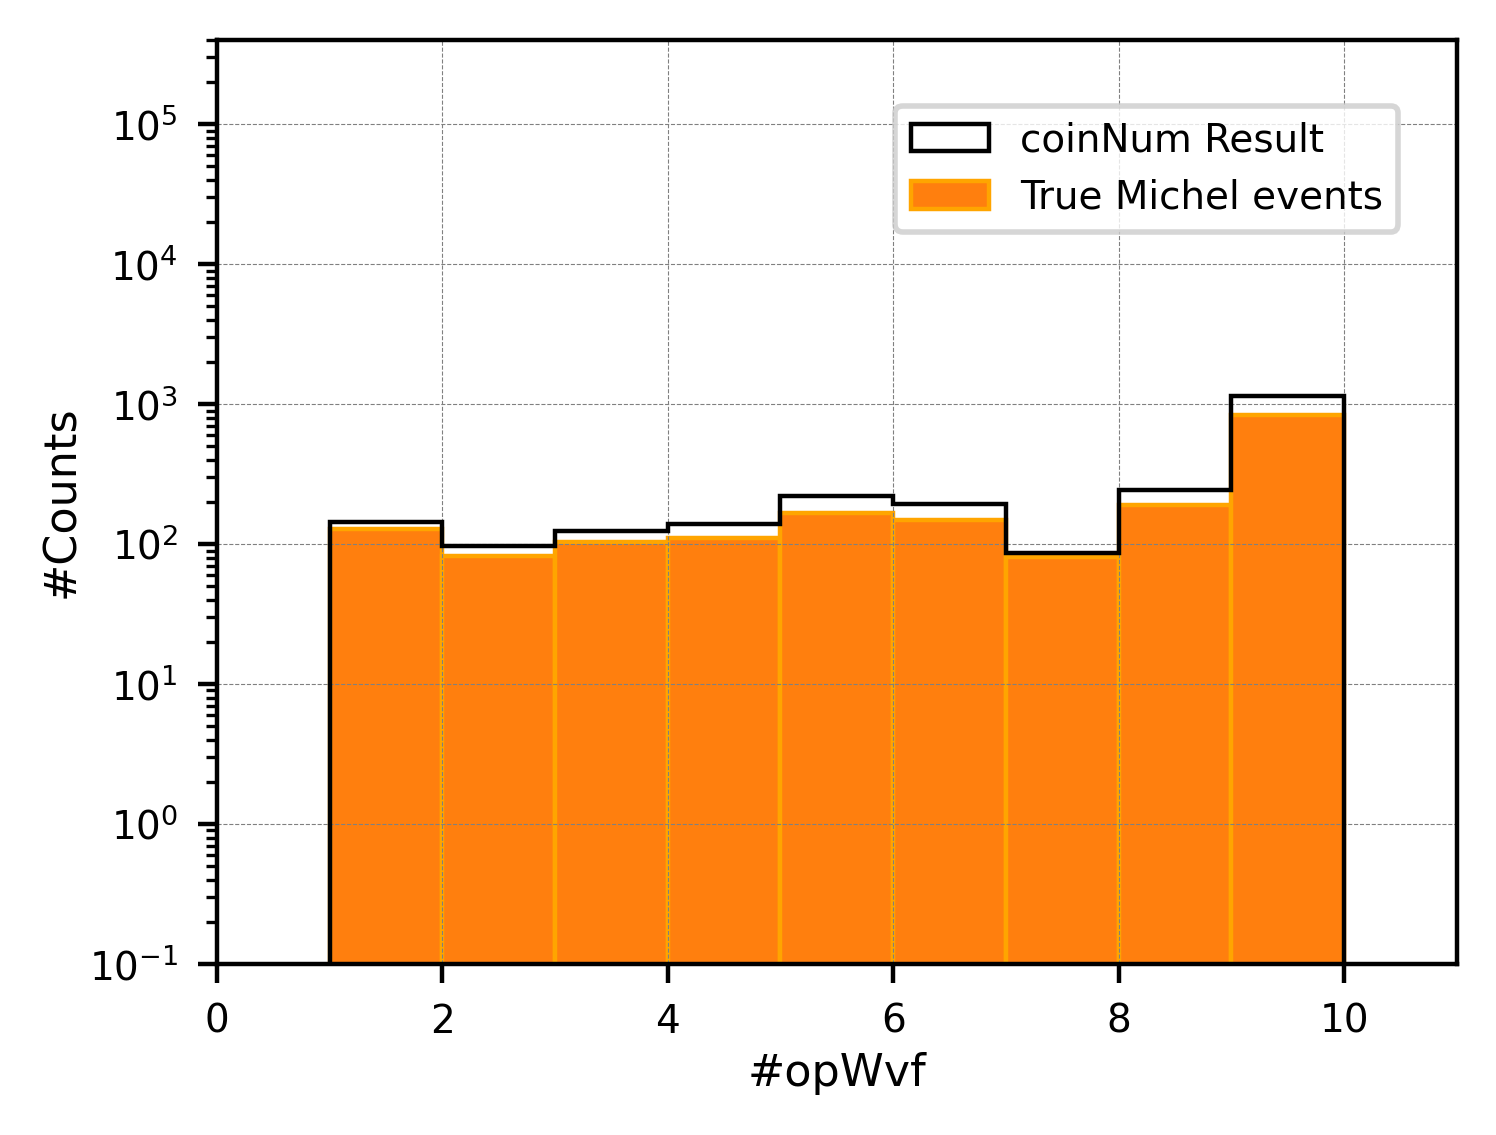

<Figure size 1600x1200 with 0 Axes>

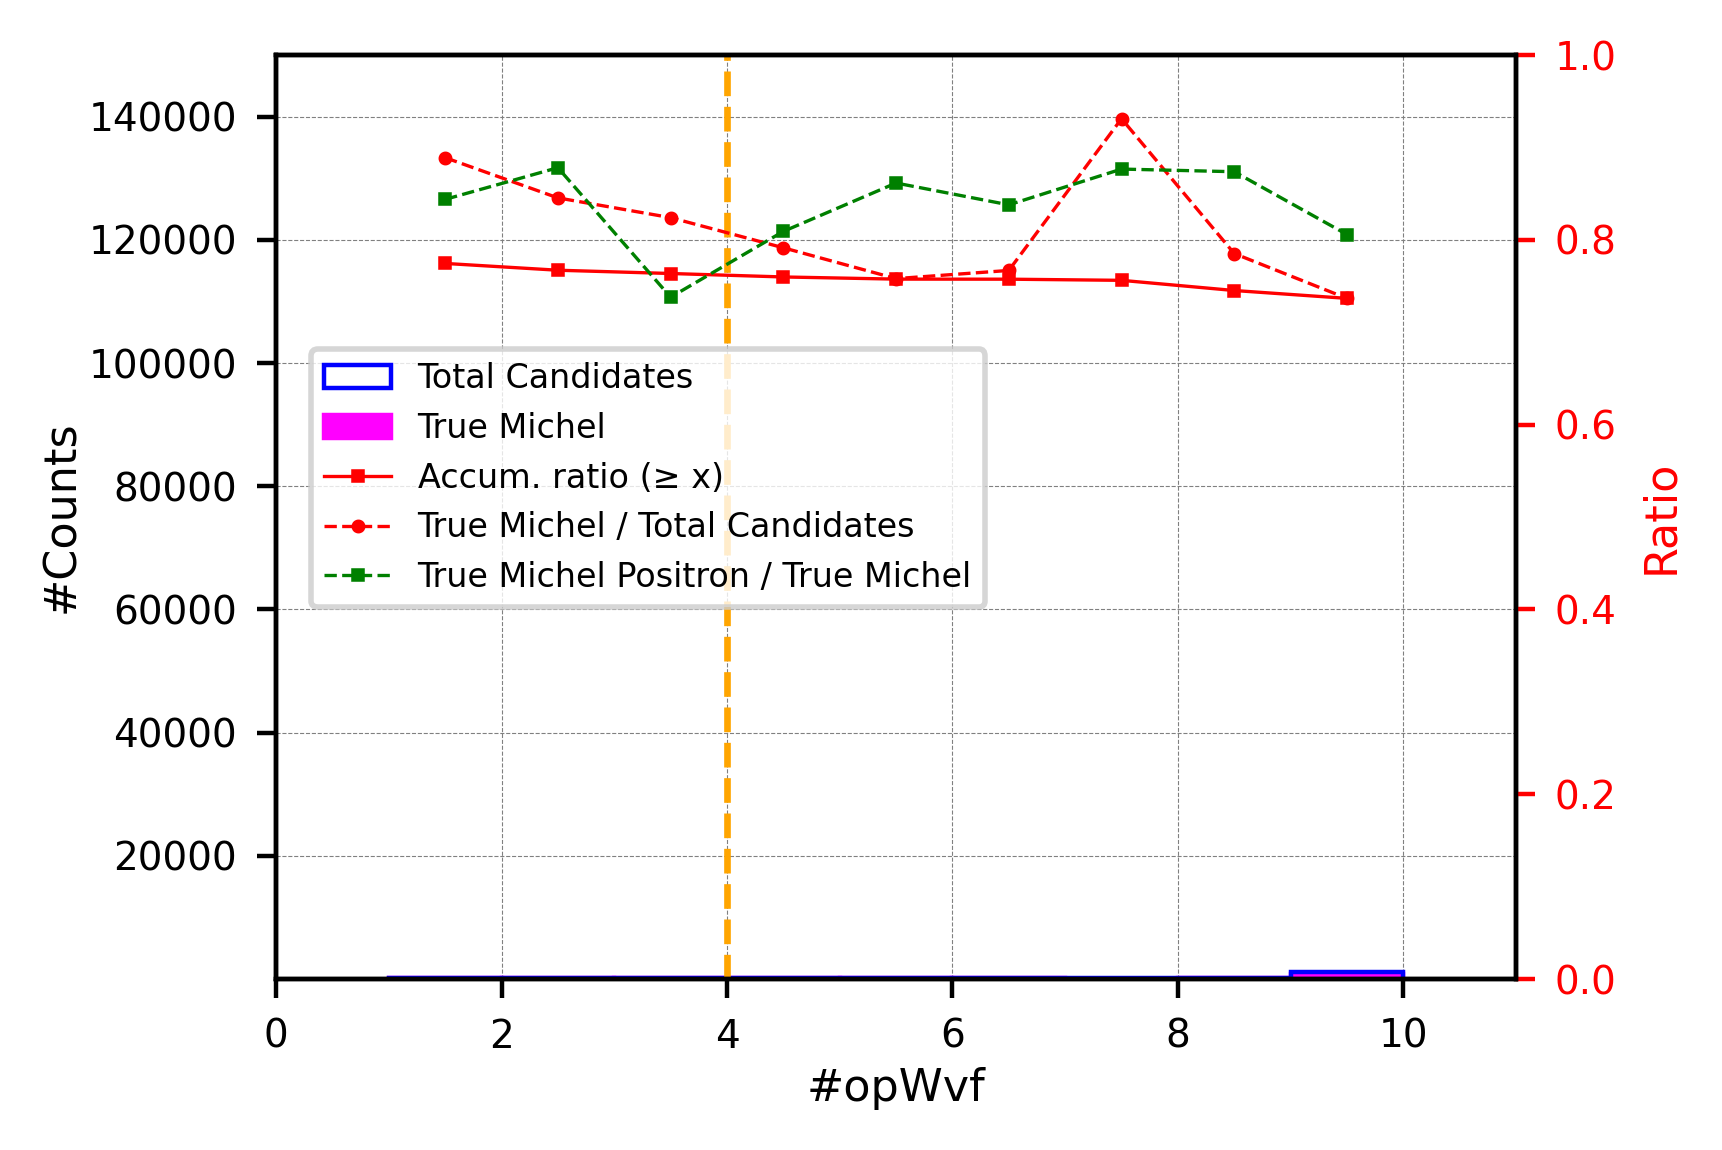

In [2]:

#Extract coinNum with trueE:===========================
coinNum_trueE = []
coinNum_trueE_e = [] #Michel electron
coinNum_trueE_p = [] #Michel positron
for i in range(0, len(coinTrueE)):
    count = coinNum[i]
    e = coinTrueE[i]
    pdg = coinPDG[i]

    if e > 0:
        coinNum_trueE.append(count)
        if pdg == 11:
            coinNum_trueE_e.append(count)
        if pdg == -11:
            coinNum_trueE_p.append(count)

print("Purity of coinNum: ", len(coinNum_trueE), "/", len(coinNum), "({:.2f}%)".format(len(coinNum_trueE)/len(coinNum)*100))
print("Michel e: ", len(coinNum_trueE_e), "/", len(coinNum_trueE), "({:.2f}%)".format(len(coinNum_trueE_e)/len(coinNum_trueE)*100))
print("Michel p: ", len(coinNum_trueE_p), "/", len(coinNum_trueE), "({:.2f}%)".format(len(coinNum_trueE_p)/len(coinNum_trueE)*100))





#Apply preliminary cut #opWvf >=4:=====================
coinNum_cut5 = []
coinNum_trueE_cut5 = []
for i in range(0, len(coinNum)):
    coin = coinNum[i]
    trueE = coinTrueE[i]

    if coin >=4:
        coinNum_cut5.append(coin)
    
        if trueE > 0:
            coinNum_trueE_cut5.append(trueE)

print("\nCandidates with #opWvf>=4: ", len(coinNum_cut5), "/", len(coinNum), "({:.2f}%)".format(len(coinNum_cut5)/len(coinNum)*100))
print("Purity: ", len(coinNum_trueE_cut5), "/", len(coinNum_cut5), "({:.2f}%)".format(len(coinNum_trueE_cut5)/len(coinNum_cut5)*100))

print("\nValues here are based on MS>0.2 & MH>2...")



# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#Define the range and bin width
bin_width = 1
range_min = 0
range_max = 11
bins = np.arange(range_min, range_max + bin_width, bin_width)

#plt.plot([5, 5], [0, 1200], color="black", linewidth=1.5, linestyle='--')

plt.hist(coinNum, bins=bins, range=(range_min, range_max), edgecolor='black', 
         histtype='step', linewidth=0.8, label='coinNum Result')
plt.hist(coinNum_trueE, bins=bins, range=(range_min, range_max), edgecolor='orange', 
         histtype='bar', linewidth=0.8, label="True Michel events")



plt.legend(loc='upper center', bbox_to_anchor=(0.75, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.xlim(0, 11)
#plt.ylim(0, 50)
plt.xlabel('#opWvf', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(0.1, 400000)
plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show() 








#Michel score distribution (Original)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

# Define the range and bin width
bin_width = 1
range_min = 1
range_max = 10
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Compute histograms
hist_total, _ = np.histogram(coinNum, bins=bins, range=(range_min, range_max))
hist_true, _ = np.histogram(coinNum_trueE, bins=bins, range=(range_min, range_max))
hist_trueP, _ = np.histogram(coinNum_trueE_p, bins=bins, range=(range_min, range_max))#True positron

# Compute bin centers (midpoints of bins)
bin_centers = bins[:-1] + bin_width / 2

fig, ax1 = plt.subplots(figsize=(4,3), dpi=400)

# Primary y-axis (Counts)
ax1.hist(bin_centers, bins=bins, weights=hist_total, edgecolor='blue', histtype='step', linewidth=0.8, label="Total Candidates")
ax1.hist(bin_centers, bins=bins, weights=hist_true, edgecolor='magenta', color='magenta', histtype='bar', 
         linewidth=0.8, label="True Michel")
#ax1.hist(bin_centers, bins=bins, weights=hist_trueP, edgecolor='green', color='green', histtype='bar', 
#         linewidth=0.8, label="True Michel Positron")


ax1.plot([4, 4], [0, 10000000], color="orange", linewidth=1.2, linestyle='--')


ax1.set_xlim(0, 11)
ax1.set_xlabel('#opWvf', labelpad=2, fontsize=8)
ax1.set_ylabel('#Counts', labelpad=1, fontsize=8)
ax1.set_ylim(0.1, 150000)
#ax1.set_yscale('log')
ax1.tick_params(labelsize=7)
ax1.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
#plt.legend(loc='upper center', bbox_to_anchor=(0.3, 0.99), fontsize=9, markerscale=5, ncol=1, prop={'size': 6})

# Secondary y-axis (Ratio)
ax2 = ax1.twinx()
ratio = np.divide(hist_true, hist_total, out=np.zeros_like(hist_true, dtype=float), where=hist_total!=0)  # Avoid division by zero

ratio2 = np.divide(hist_trueP, hist_true, out=np.zeros_like(hist_trueP, dtype=float), where=hist_total!=0)  # Avoid division by zero

# --- Accumulated (>= x) ratio ---
# Cumulative sums from the right (>= x)
cum_total = np.cumsum(hist_total[::-1])[::-1]
cum_true  = np.cumsum(hist_true[::-1])[::-1]
acc_ratio = np.divide(cum_true, cum_total,
                      out=np.zeros_like(cum_true, dtype=float),
                      where=cum_total != 0)

# Add the accumulated ratio curve on the secondary y-axis
ax2.plot(bin_centers, acc_ratio, color='red', marker='s', markersize=1.5,
         linestyle='-', linewidth=0.6, label='Accum. ratio (≥ x)')


ax2.plot(bin_centers, ratio, color='red', marker='o', markersize=1.5, linestyle='--', 
         linewidth=0.6, label="True Michel / Total Candidates")

ax2.plot(bin_centers, ratio2, color='green', marker='s', markersize=1.5, linestyle='--', 
         linewidth=0.6, label="True Michel Positron / True Michel")



ax2.set_ylabel('Ratio', fontsize=8, color='red')
ax2.set_ylim(0.0, 1.0)

ax2.tick_params(axis='y', labelsize=7, colors='red')



# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper center', bbox_to_anchor=(0.3, 0.7),
           fontsize=9, ncol=1, prop={'size': 6})



plt.show()



<br />
<br />
<br />
<br />
<br />
<br />

## Process WVF:
### After TPC cuts & (#opWvf >= 4) (This can be taken as "PDS Cut 1")

In [4]:
from dataclasses import dataclass
from typing import Optional
import matplotlib.pyplot as plt
import numpy as np
import re
from mpl_toolkits.mplot3d import Axes3D



# ------------------- Dataclass -------------------
@dataclass
class PdsEvent:
    muon_time: Optional[int] = None
    michel_time: Optional[int] = None
    third_time: Optional[int] = None             # NEW
    muon_intensity: Optional[float] = None
    michel_intensity: Optional[float] = None
    third_intensity: Optional[float] = None      # NEW
    posX: Optional[float] = None
    posY: Optional[float] = None
    posZ: Optional[float] = None
    energy: Optional[float] = None
    lifetime: Optional[float] = None
    pdg: Optional[int] = None
    eventID: Optional[int] = None
    trackID: Optional[int] = None
    date: Optional[int] = None
    # muon
    mu_leftTurn: Optional[int] = None
    mu_rightTurn: Optional[int] = None
    mu_leftHeight: Optional[float] = None
    mu_rightHeight: Optional[float] = None
    # michel
    mi_leftTurn: Optional[int] = None
    mi_rightTurn: Optional[int] = None
    mi_leftHeight: Optional[float] = None
    mi_rightHeight: Optional[float] = None
    # third peak
    th_leftTurn: Optional[int] = None            # NEW
    th_rightTurn: Optional[int] = None           # NEW
    th_leftHeight: Optional[float] = None        # NEW
    th_rightHeight: Optional[float] = None       # NEW
    # Michel-level attributes
    michel_score: Optional[float] = None         # ✅ NEW
    michel_hits: Optional[int] = None            # ✅ NEW



# ------------------- Helpers -------------------
def parse_event_track(path_str: str):
    """Extract eventID and trackID from a file path string."""
    m = re.search(r"event(\d+)_trackID(\d+)", path_str)
    if m:
        return int(m.group(1)), int(m.group(2))
    return None, None



def read_total_files(files, dates, kind="muon"):
    """
    Read *_total_xxx.txt files.
    Each line: path: t, I, leftTurn, leftHeight, rightTurn, rightHeight
    """
    records = []
    for fname, date in zip(files, dates):
        try:
            with open(fname, "r") as f:
                for line in f:
                    line = line.strip()
                    if not line:
                        continue
                    parts = line.split(":")
                    if len(parts) < 2:
                        continue

                    path_part = parts[0].strip()
                    values = [v.strip() for v in parts[1].split(",")]
                    if len(values) < 6:
                        print(f"[WARN] Malformed line in {fname}: {line}")
                        continue

                    try:
                        time_val = int(values[0])
                        inten_val = float(values[1])
                        left_turn = int(values[2])
                        left_h = float(values[3])
                        right_turn = int(values[4])
                        right_h = float(values[5])
                    except ValueError:
                        print(f"[WARN] Could not parse numbers in {line}")
                        continue

                    evID, trID = parse_event_track(path_part)
                    rec = {"eventID": evID, "trackID": trID, "date": int(date)}

                    if kind == "muon":
                        rec.update({
                            "muon_time": time_val,
                            "muon_intensity": inten_val,
                            "mu_leftTurn": left_turn,
                            "mu_leftHeight": left_h,
                            "mu_rightTurn": right_turn,
                            "mu_rightHeight": right_h
                        })
                    elif kind == "michel":
                        rec.update({
                            "michel_time": time_val,
                            "michel_intensity": inten_val,
                            "mi_leftTurn": left_turn,
                            "mi_leftHeight": left_h,
                            "mi_rightTurn": right_turn,
                            "mi_rightHeight": right_h
                        })
                    elif kind == "third":
                        rec.update({
                            "third_time": time_val,
                            "third_intensity": inten_val,
                            "th_leftTurn": left_turn,
                            "th_leftHeight": left_h,
                            "th_rightTurn": right_turn,
                            "th_rightHeight": right_h
                        })

                    records.append(rec)
        except FileNotFoundError:
            print(f"File not found: {fname}")
    return records




def read_plain_files(files, cast_type=float):
    """Read one or more plain text files with one number per line and return concatenated values."""
    values = []
    for fname in files:
        try:
            with open(fname, "r") as file:
                for line in file:
                    value = line.strip()
                    if value:
                        try:
                            values.append(cast_type(value))
                        except ValueError:
                            print(f"Could not convert {value} in {fname}")
        except FileNotFoundError:
            print(f"File not found: {fname}")
    return values



# ------------------- Load data -------------------
# ------------------- Load data (TWO GROUPS) -------------------

data_groups = [
    {
        "data_dir": "./statResult_pds",
        "dates": ["20251101", "20251102"
                  ]
    }
]

muon_records   = []
michel_records = []
third_records  = []

posX, posY, posZ = [], [], []
energy, lifetime = [], []
pdg = []
miScore, miHits = [], []

print("\n================= Reading multi-group files =================\n")

for group in data_groups:
    dir0  = group["data_dir"]
    dates = group["dates"]

    print(f"\n[GROUP] Reading from: {dir0}\n")

    # ------------------- A. TOTAL FILES -------------------
    muon_files   = [f"{dir0}/muon_total_{d}.txt"   for d in dates]
    michel_files = [f"{dir0}/michel_total_{d}.txt" for d in dates]
    third_files  = [f"{dir0}/third_total_{d}.txt"  for d in dates]

    print("→ Reading MUON TOTAL files...")
    recs = read_total_files(muon_files, dates, kind="muon")
    print(f"  Loaded {len(recs)} muon records\n")
    muon_records.extend(recs)

    print("→ Reading MICHEL TOTAL files...")
    recs = read_total_files(michel_files, dates, kind="michel")
    print(f"  Loaded {len(recs)} michel records\n")
    michel_records.extend(recs)

    print("→ Reading THIRD TOTAL files...")
    recs = read_total_files(third_files, dates, kind="third")
    print(f"  Loaded {len(recs)} third records\n")
    third_records.extend(recs)


    # ------------------- B. PLAIN FILES -------------------
    print("→ Reading plain-text extracted files...\n")

    posX.extend(     read_plain_files([f"{dir0}/posX_extract_{d}.txt" for d in dates]) )
    posY.extend(     read_plain_files([f"{dir0}/posY_extract_{d}.txt" for d in dates]) )
    posZ.extend(     read_plain_files([f"{dir0}/posZ_extract_{d}.txt" for d in dates]) )
    energy.extend(   read_plain_files([f"{dir0}/energy_extract_{d}.txt" for d in dates]) )
    lifetime.extend( read_plain_files([f"{dir0}/lifetime_extract_{d}.txt" for d in dates]) )
    pdg.extend(      read_plain_files([f"{dir0}/pdg_extract_{d}.txt" for d in dates], cast_type=int) )
    miScore.extend(  read_plain_files([f"{dir0}/michelScore_extract_{d}.txt" for d in dates]) )
    miHits.extend(   read_plain_files([f"{dir0}/michelHits_extract_{d}.txt"  for d in dates], cast_type=int) )


print("\n================= SUMMARY OF COUNTS =================")
print("Muon total records   :", len(muon_records))
print("Michel total records :", len(michel_records))
print("Third total records  :", len(third_records))
print("posX length          :", len(posX))
print("posY length          :", len(posY))
print("posZ length          :", len(posZ))
print("energy length        :", len(energy))
print("lifetime length      :", len(lifetime))
print("pdg length           :", len(pdg))
print("michelScore length   :", len(miScore))
print("michelHits length    :", len(miHits))
print("=====================================================\n")



# ------------------- Build dataset -------------------
events_veryInitial = []
n_events = min(
    len(muon_records), len(michel_records), len(third_records),
    len(posX), len(posY), len(posZ),
    len(energy), len(lifetime), len(pdg),
    len(miScore), len(miHits)
)

for i in range(n_events):
    rec_mu = muon_records[i]
    rec_mi = michel_records[i]
    rec_th = third_records[i]

    ev = PdsEvent(
        eventID=rec_mu.get("eventID", rec_mi.get("eventID", rec_th.get("eventID"))),
        trackID=rec_mu.get("trackID", rec_mi.get("trackID", rec_th.get("trackID"))),
        date=rec_mu.get("date", rec_mi.get("date", rec_th.get("date"))),

        # muon
        muon_time=rec_mu.get("muon_time"),
        muon_intensity=rec_mu.get("muon_intensity"),
        mu_leftTurn=rec_mu.get("mu_leftTurn"),
        mu_leftHeight=rec_mu.get("mu_leftHeight"),
        mu_rightTurn=rec_mu.get("mu_rightTurn"),
        mu_rightHeight=rec_mu.get("mu_rightHeight"),

        # michel
        michel_time=rec_mi.get("michel_time"),
        michel_intensity=rec_mi.get("michel_intensity"),
        mi_leftTurn=rec_mi.get("mi_leftTurn"),
        mi_leftHeight=rec_mi.get("mi_leftHeight"),
        mi_rightTurn=rec_mi.get("mi_rightTurn"),
        mi_rightHeight=rec_mi.get("mi_rightHeight"),
        michel_score=miScore[i],
        michel_hits=miHits[i],

        # third
        third_time=rec_th.get("third_time"),
        third_intensity=rec_th.get("third_intensity"),
        th_leftTurn=rec_th.get("th_leftTurn"),
        th_leftHeight=rec_th.get("th_leftHeight"),
        th_rightTurn=rec_th.get("th_rightTurn"),
        th_rightHeight=rec_th.get("th_rightHeight"),

        # physical properties
        posX=posX[i], posY=posY[i], posZ=posZ[i],
        energy=energy[i], lifetime=lifetime[i], pdg=pdg[i]
    )
    events_veryInitial.append(ev)

print("Very initial dataset:", len(events_veryInitial))

example = events_veryInitial[0]
print("\nExample Event (index 0):")
for field, value in vars(example).items():
    print(f"  {field:20s}: {value}")









#Apply cuts on peak intensities-----------------------------
events_reco_initial = []
events_true_initial = []

for ev in events_veryInitial:
    muIntensity = ev.muon_intensity
    miIntensity = ev.michel_intensity
    e = ev.energy

    ms = ev.michel_score
    mh = ev.michel_hits

    #mu & mi are cuts in following block already!
    if muIntensity > -0.1  and miIntensity > -0.1 and ms > 0.2 and mh > 2:
        events_reco_initial.append(ev)

        if e > 0:
            events_true_initial.append(ev)

print("\nDataset after initial intensity-cut----------------------")
print("Michel initial dataset   : ", len(events_reco_initial))
print("Michel purity (true/reco): ", len(events_true_initial), "/ ", len(events_reco_initial), 
      "({:.2f}%)".format(len(events_true_initial)/len(events_reco_initial)*100)) 








================= Reading multi-group files =================


[GROUP] Reading from: ./statResult_pds

→ Reading MUON TOTAL files...
  Loaded 2019 muon records

→ Reading MICHEL TOTAL files...
  Loaded 2019 michel records

→ Reading THIRD TOTAL files...
  Loaded 2019 third records

→ Reading plain-text extracted files...


================= SUMMARY OF COUNTS =================
Muon total records   : 2019
Michel total records : 2019
Third total records  : 2019
posX length          : 2019
posY length          : 2019
posZ length          : 2019
energy length        : 2019
lifetime length      : 2019
pdg length           : 2019
michelScore length   : 2019
michelHits length    : 2019

Very initial dataset: 2019

Example Event (index 0):
  muon_time           : 126
  michel_time         : 219
  third_time          : 164
  muon_intensity      : 3.7129
  michel_intensity    : 0.598479
  third_intensity     : 0.399324
  posX                : -80.4724
  posY                : 95.8484
  posZ     

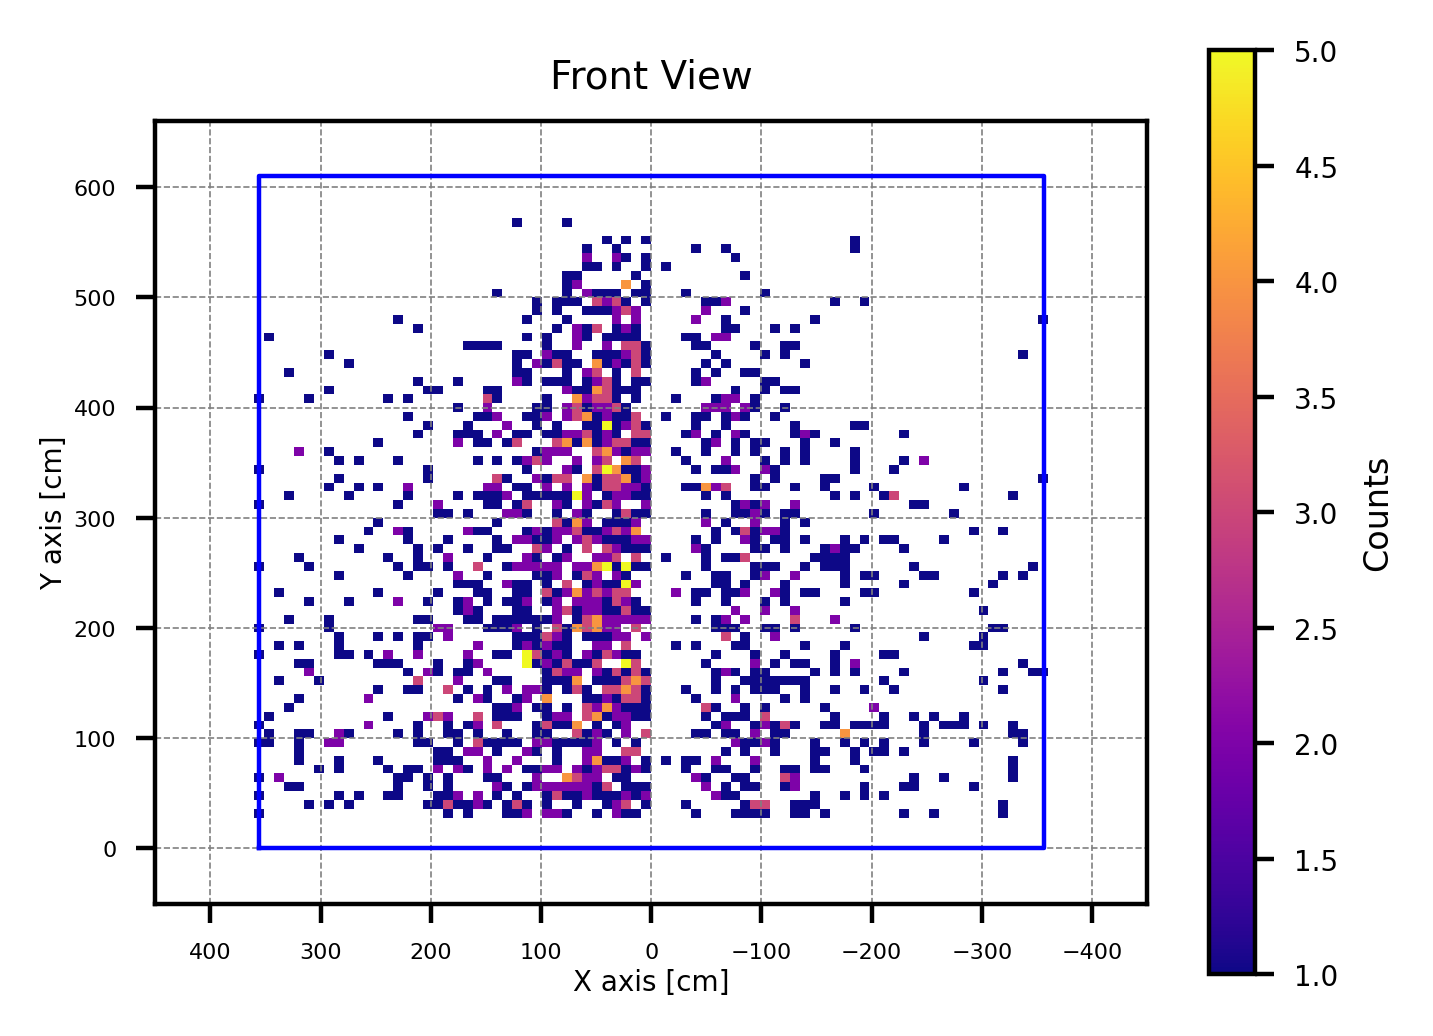

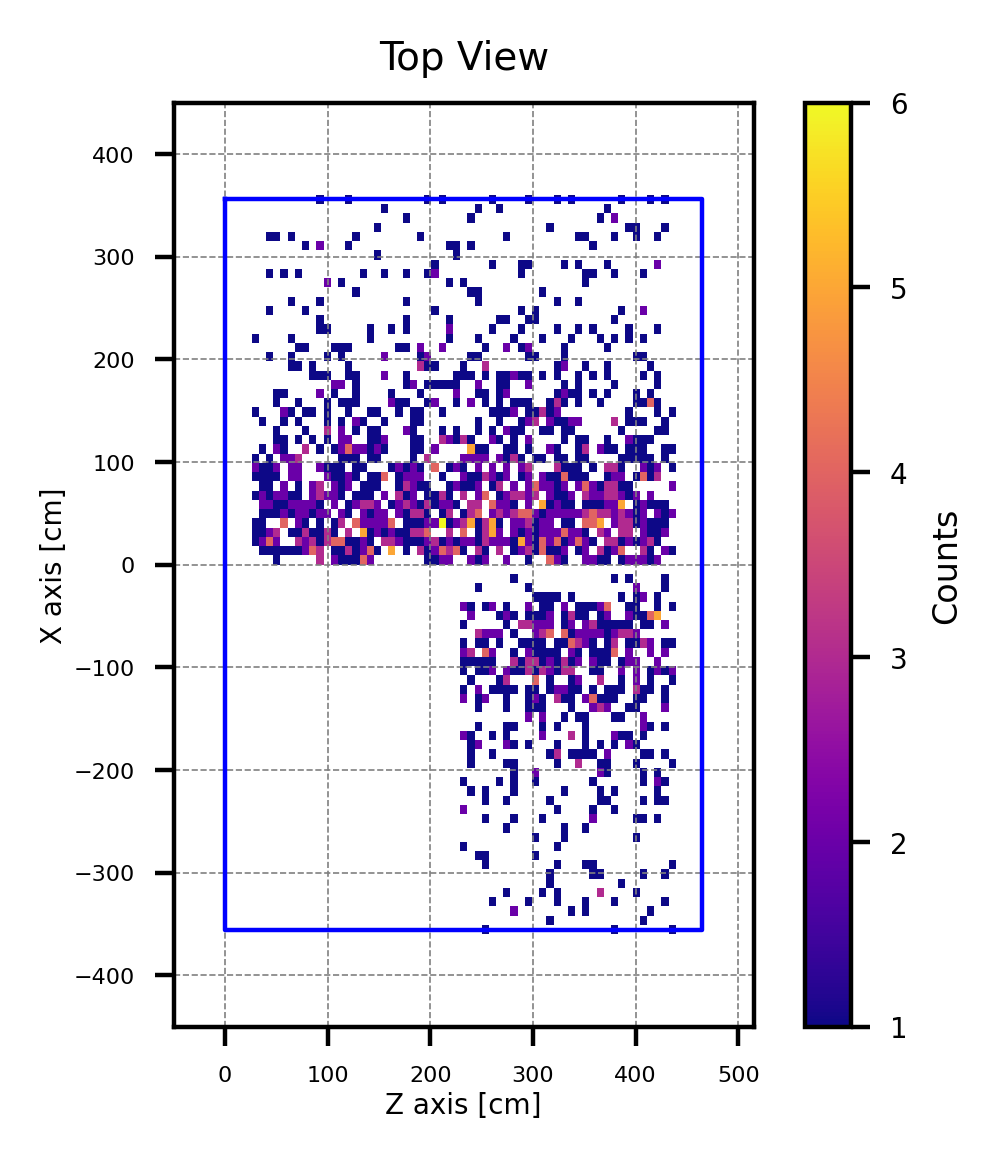


Decay points distribution (TPC & #opWvf cuts): 
# of X < 0 :  551 (27.29%)
# of X >= 0:  1468 (72.71%)

Michel purity:  1534 /  2019 (75.98%)

Bin Center | Final / Initial Ratio
-------------------------------
   -355.0 | 0.000
   -345.0 | 0.500
   -335.0 | 0.500
   -325.0 | 0.286
   -315.0 | 0.667
   -305.0 | 0.000
   -295.0 | 0.600
   -285.0 | 0.500
   -275.0 | 0.667
   -265.0 | 0.000
   -255.0 | 0.250
   -245.0 | 0.714
   -235.0 | 0.667
   -225.0 | 0.778
   -215.0 | 0.778
   -205.0 | 0.750
   -195.0 | 0.800
   -185.0 | 0.938
   -175.0 | 0.667
   -165.0 | 0.556
   -155.0 | 0.727
   -145.0 | 0.643
   -135.0 | 0.810
   -125.0 | 0.583
   -115.0 | 0.875
   -105.0 | 0.816
    -95.0 | 0.842
    -85.0 | 0.714
    -75.0 | 0.550
    -65.0 | 0.780
    -55.0 | 0.641
    -45.0 | 0.750
    -35.0 | 0.706
    -25.0 | 0.667
    -15.0 | 1.000
     -5.0 | 1.000
      5.0 | 0.887
     15.0 | 0.917
     25.0 | 0.925
     35.0 | 0.930
     45.0 | 0.782
     55.0 | 0.815
     65.0 | 0.760
     75.0 | 0.8

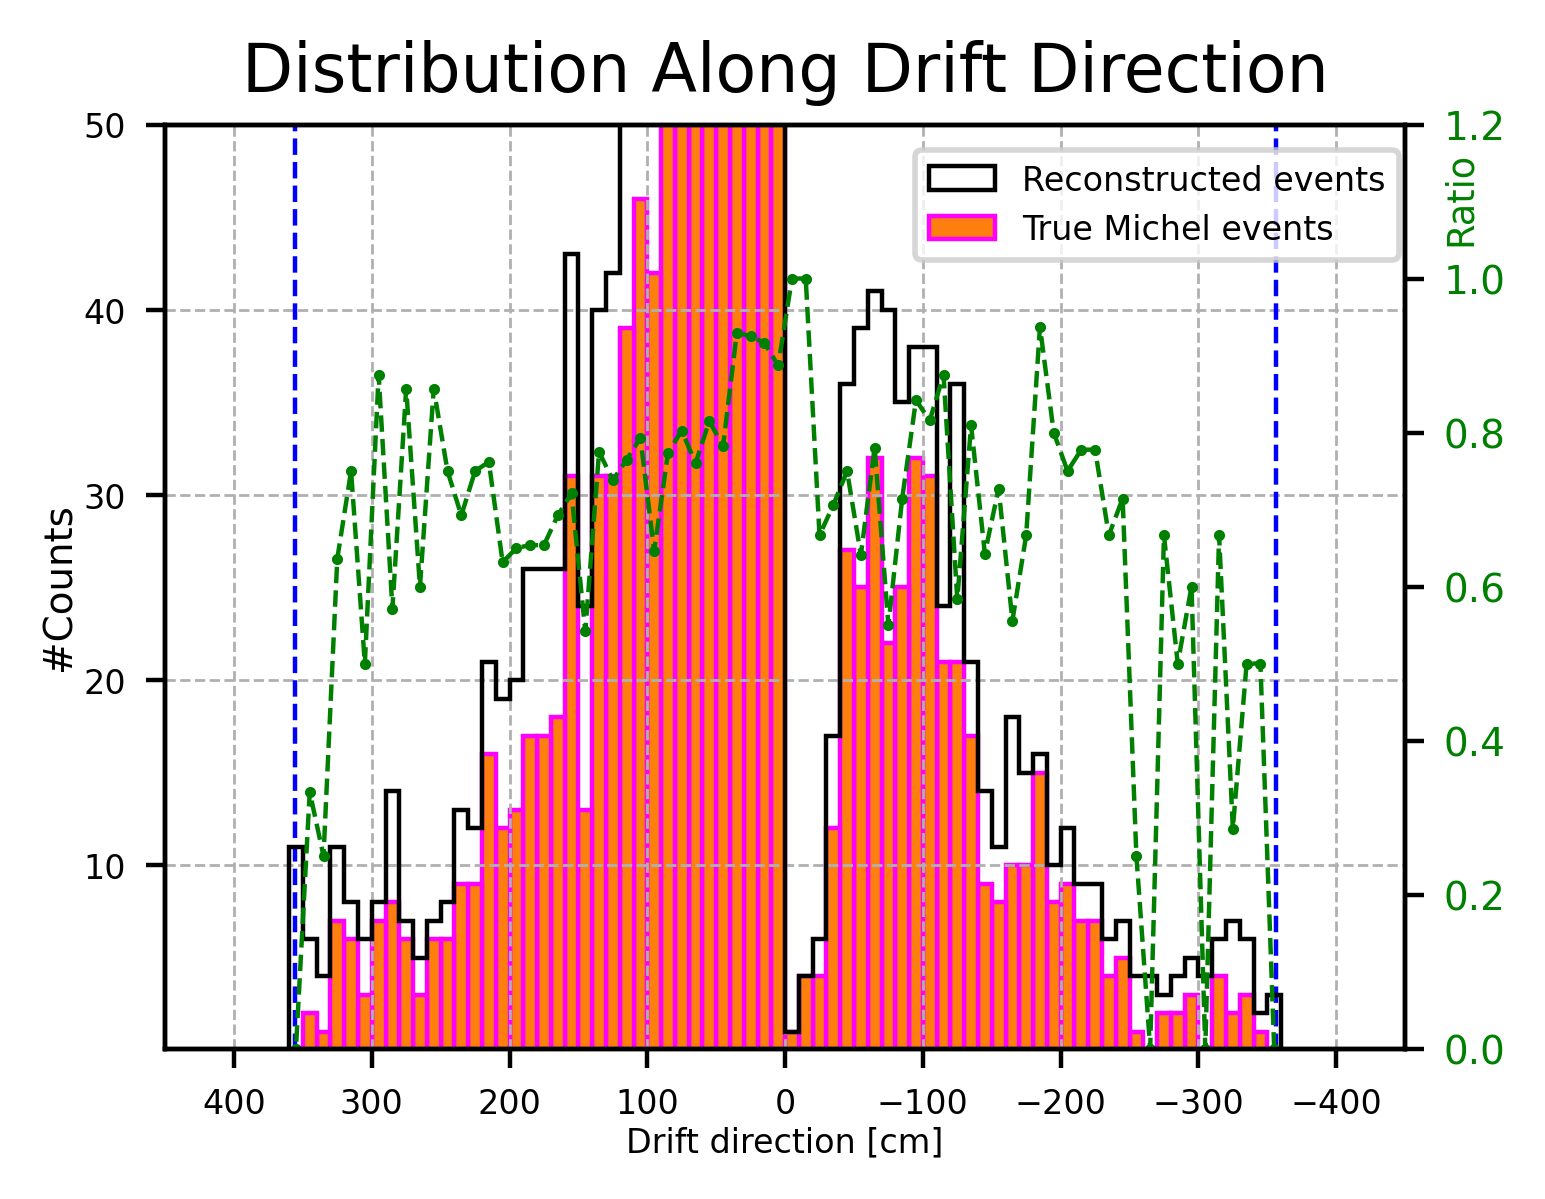

In [5]:
posX = [ev.posX for ev in events_reco_initial]
posY = [ev.posY for ev in events_reco_initial]
posZ = [ev.posZ for ev in events_reco_initial]

posX_true = [ev.posX for ev in events_true_initial]




#Y-X plane ploting (Front View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#Set the limts of x, y and z when drawing---
xmin = -450
xmax = 450
ymin = -100
ymax = 700
zmin = -100
zmax = 600

#Field cage range---
cageMinX = -356
cageMaxX = 356
cageMinY = 0
cageMaxY = 610
cageMinZ = 0
cageMaxZ = 465


#auxiliary line, along y(geo) and x axis---
aux2 = [0, 610, 610, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')


# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(posX, posY, bins=(100, 100), range=[[xmin, xmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar()
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-450, 450)#z---
plt.ylim(-50, 660)
plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Front View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 




#Z-X plane ploting (Top View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux1 = [0, 465, 465, 0, 0] #y shoud be y---
aux2 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(posZ, posX, bins=(100, 100), range=[[zmin, zmax], [xmin, xmax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.3)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)

plt.axis('scaled')
plt.ylim(-450, 450)#z---
plt.xlim(-50, 515)
plt.ylabel('X axis [cm]', labelpad=1, fontsize=5)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.title('Top View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show()








#Decay points distribution:==================================================================
print("\nDecay points distribution (TPC & #opWvf cuts): ")

posX = np.array(posX)
neg_X = np.sum(posX < 0)
pos_X = np.sum(posX >= 0)
print("# of X < 0 : ", neg_X, "({:.2f}%)".format(neg_X/len(posX)*100))
print("# of X >= 0: ", pos_X, "({:.2f}%)".format(pos_X/len(posX)*100))

print("\nMichel purity: ", len(events_true_initial), "/ ", len(events_reco_initial), 
      "({:.2f}%)".format(len(events_true_initial)/len(events_reco_initial)*100))         



# Plotting the histogram (X distribution)---------------
fig, ax1 = plt.subplots(figsize=(4, 3), dpi=400)

#Define the range and bin width
bin_width = 10
range_min = -400
range_max = 400
bins = np.arange(range_min, range_max + bin_width, bin_width)
bin_centers = (bins[:-1] + bins[1:]) / 2

# --- Histogram counts ---
n_initial, _ = np.histogram(posX, bins=bins)
n_final, _ = np.histogram(posX_true, bins=bins)

# --- Ratio Calculation (only for [-360, 360]) ---
ratio = []
ratio_centers = []

print("\nBin Center | Final / Initial Ratio")
print("-------------------------------")
for center, ni, nf in zip(bin_centers, n_initial, n_final):
    if -360 <= center <= 360:
        r = nf / ni if ni > 0 else np.nan
        ratio.append(r)
        ratio_centers.append(center)
        if ni > 0:
            print(f"{center:9.1f} | {r:.3f}")
        else:
            print(f"{center:9.1f} |   NaN")


# Filter out NaN values for min/max calculation
valid_ratios = [r for r in ratio if not np.isnan(r)]

if valid_ratios:
    print("\nMaximum ratio: {:.3f}".format(np.max(valid_ratios)))
    print("Minimum ratio: {:.3f}".format(np.min(valid_ratios)))
else:
    print("\nNo valid ratios to compute min/max.")

#APA planes---
plt.plot([-356, -356], [0, 10000], color="blue", linewidth=0.8, linestyle='--')
plt.plot([356, 356], [0, 10000], color="blue", linewidth=0.8, linestyle='--')

# Plot histograms
ax1.hist(bins[:-1], bins=bins, weights=n_initial, edgecolor='black',
         histtype='step', linewidth=0.8, label='Reconstructed events')
ax1.hist(bins[:-1], bins=bins, weights=n_final, edgecolor='magenta',
         histtype='bar', linewidth=0.8, label='True Michel events')

ax1.set_ylabel('Counts')
ax1.grid(True, linestyle='--', linewidth=0.5)
ax1.legend(loc='upper center', bbox_to_anchor=(0.8, 0.99), fontsize=9, markerscale=5, ncol=1, prop={'size': 6})
ax1.set_xlim(-450, 450)
ax1.set_ylim(0.1, 50)
ax1.set_xlabel('Drift direction [cm]', labelpad=1, fontsize=6)
ax1.set_ylabel('#Counts', labelpad=1, fontsize=7)
ax1.invert_xaxis()
#ax1.set_yscale('log')
ax1.tick_params(labelsize=6)

# Secondary y-axis for ratio
ax2 = ax1.twinx()

ax2.plot(ratio_centers, ratio, 'o--', color='green', markersize=1, linewidth=0.8, label='Final / Initial Ratio')

ax2.set_ylabel('Ratio', labelpad=1, fontsize=6.6, color='green', rotation=90)
ax2.yaxis.set_label_position("right")
ax2.yaxis.set_label_coords(1.03, 0.92)  # (x, y) in axis coordinates

ax2.tick_params(labelsize=7, axis='y', labelcolor='green')
ax2.set_ylim(0, np.nanmax(ratio) * 1.2)

# Final layout
#plt.tight_layout()

plt.title('Distribution Along Drift Direction', fontsize=12)

plt.show()



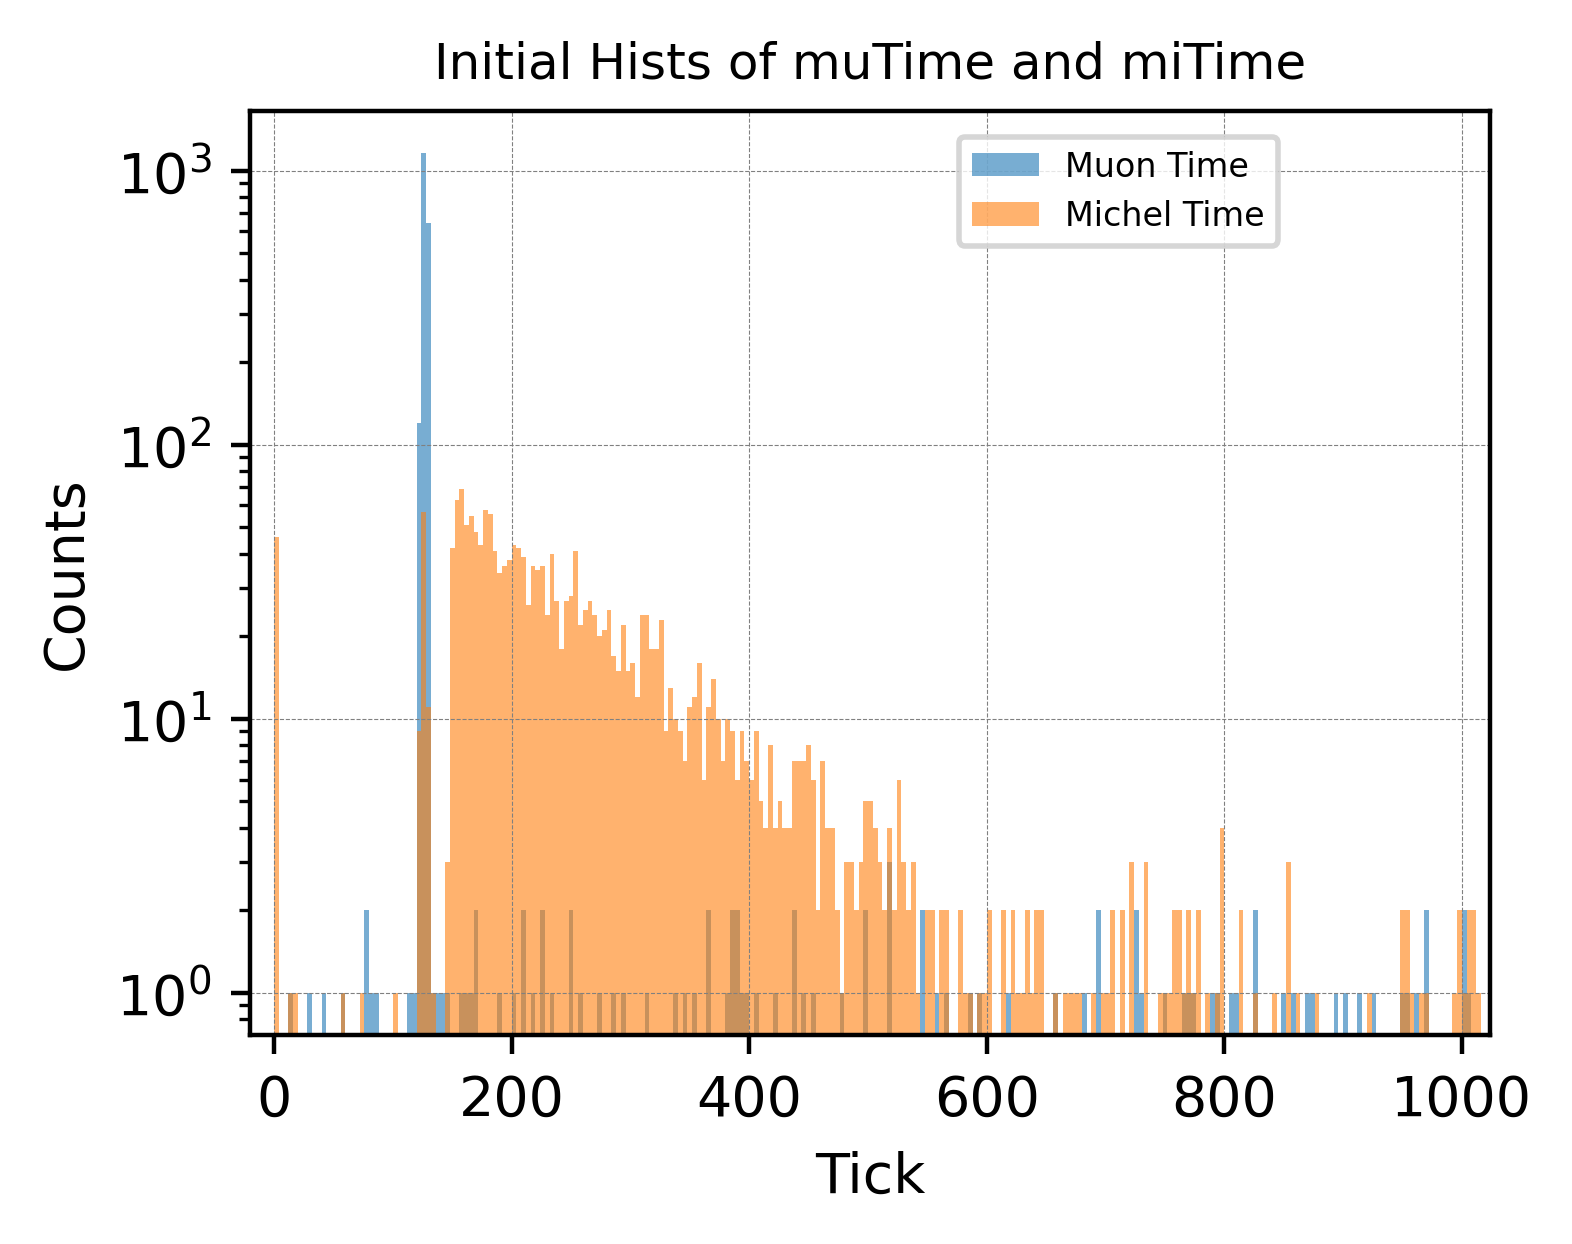

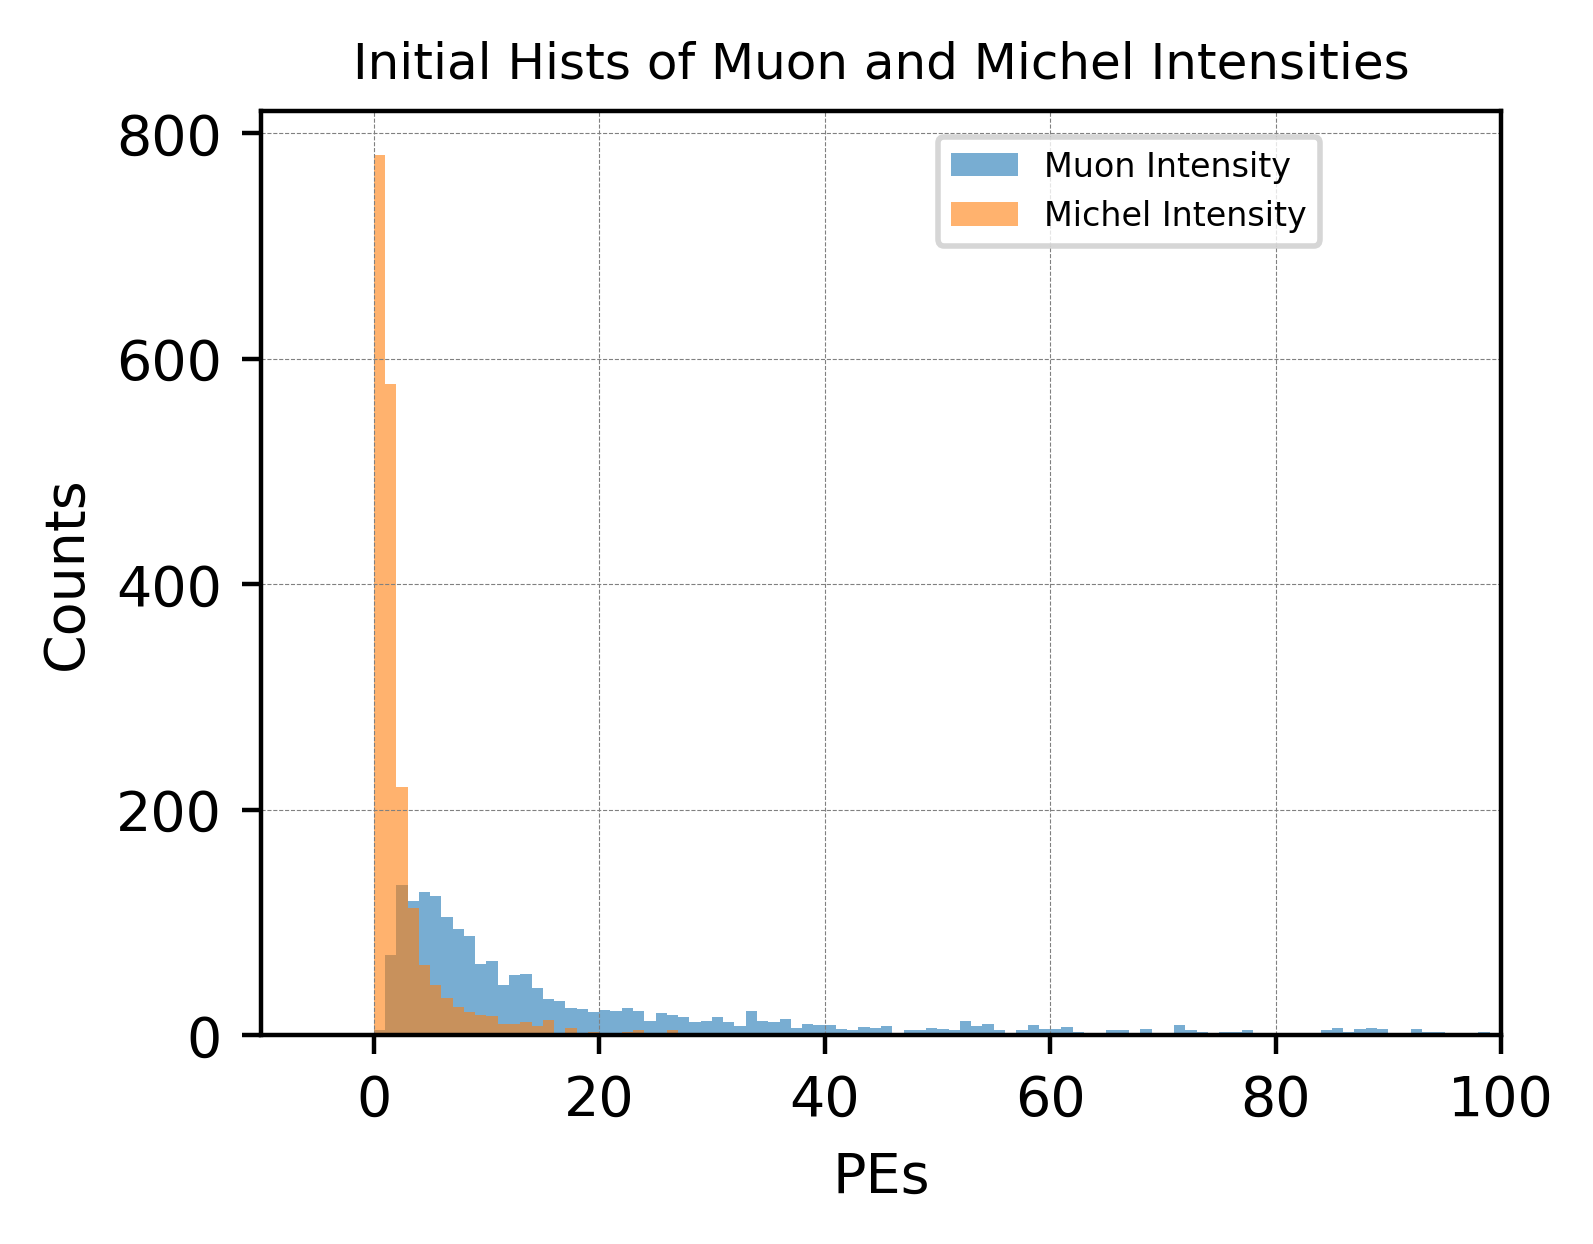

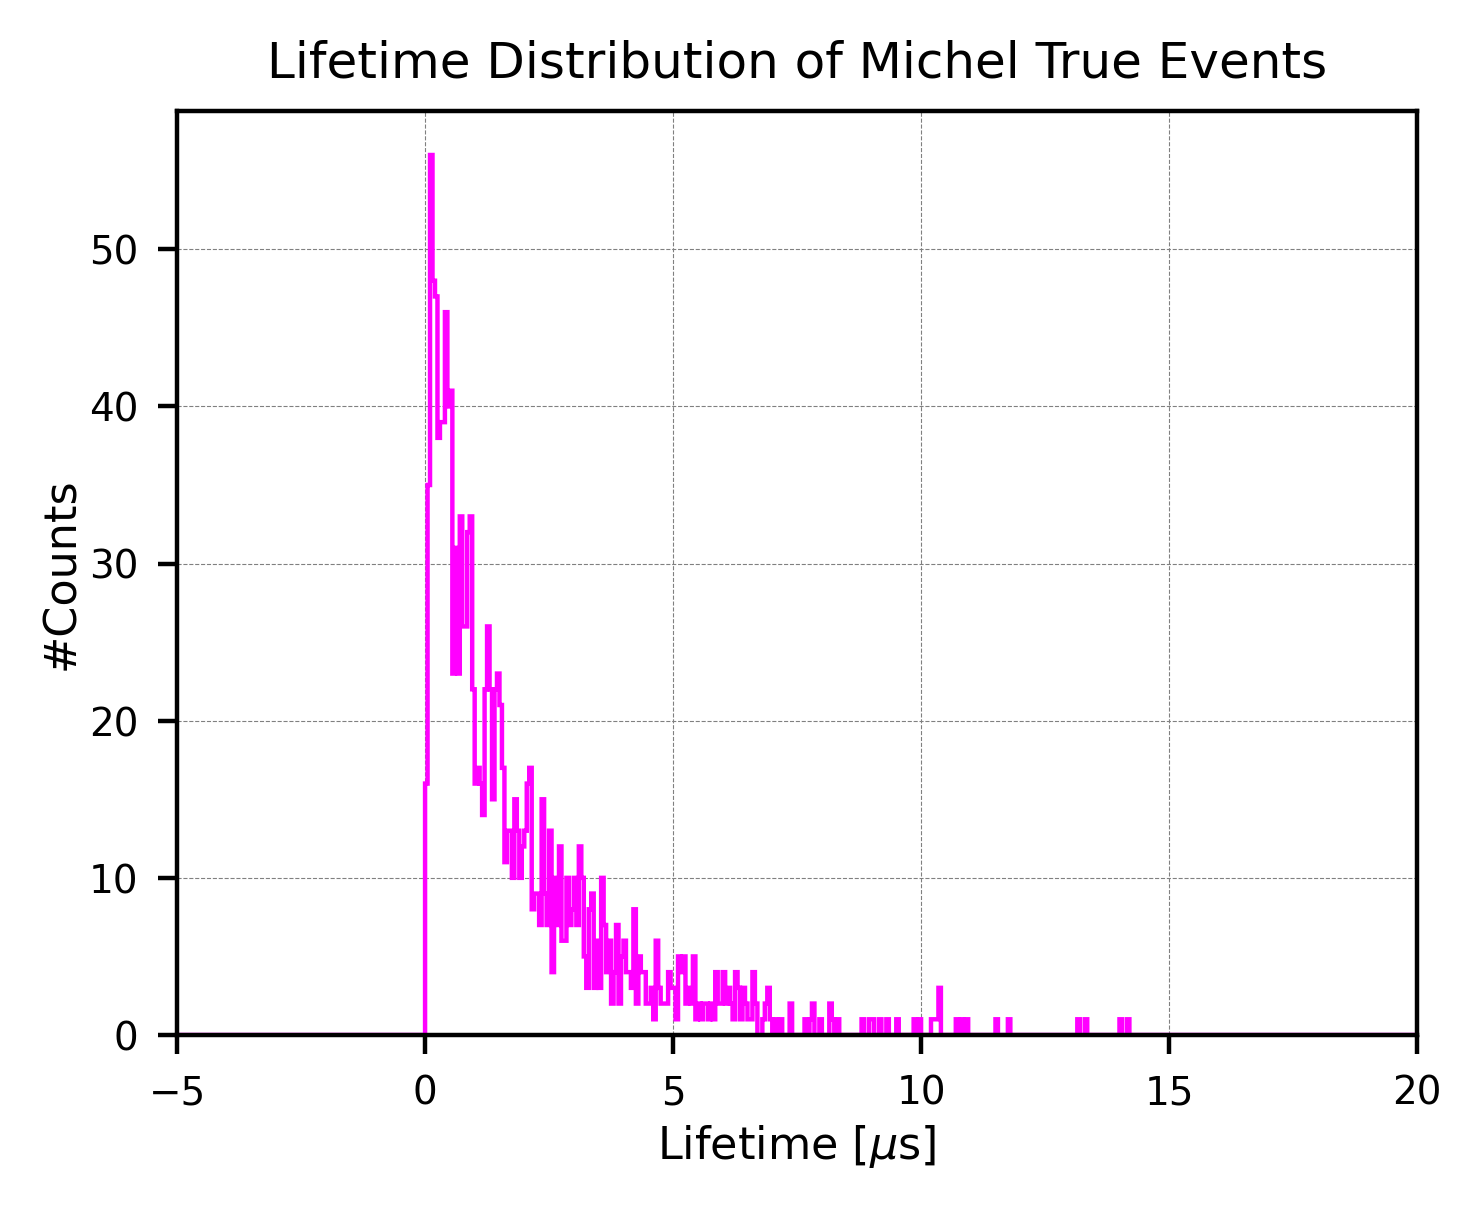

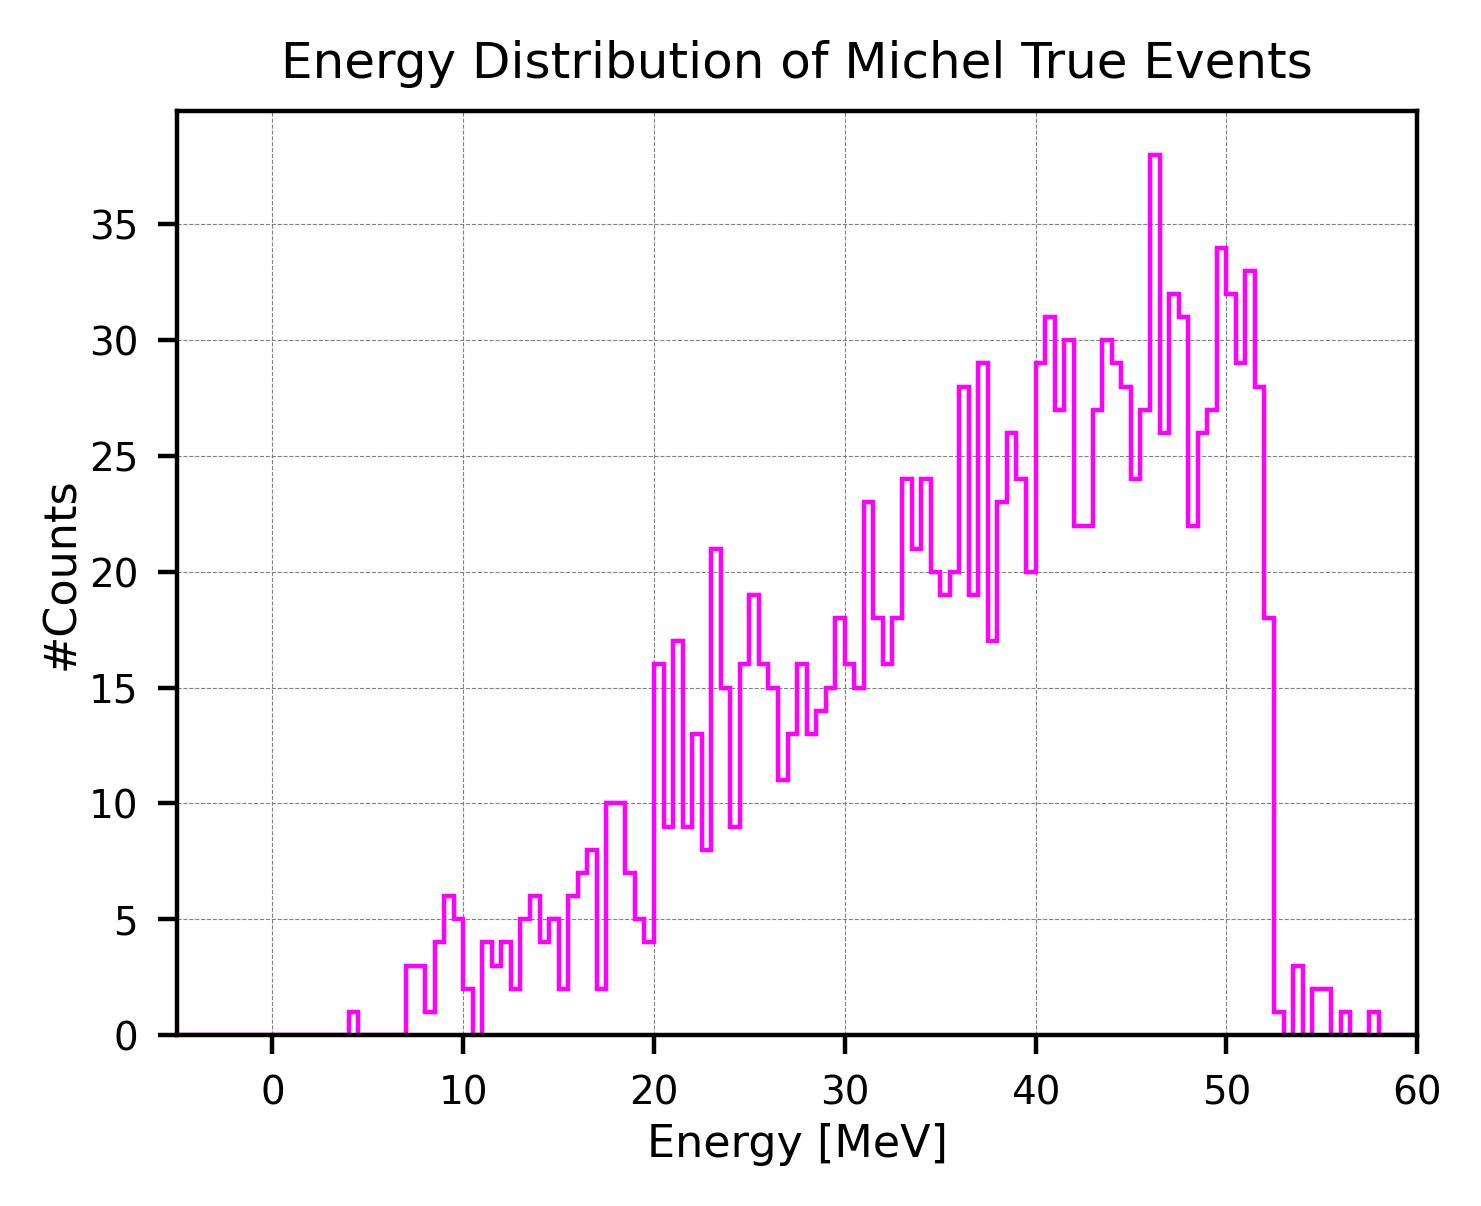

In [6]:
muon_time = [ev.muon_time for ev in events_reco_initial]
michel_time = [ev.michel_time for ev in events_reco_initial]

muon_intensity = [ev.muon_intensity for ev in events_reco_initial]
michel_intensity = [ev.michel_intensity for ev in events_reco_initial]

lifetime = [ev.lifetime for ev in events_true_initial] #true lifetime---
energy = [ev.energy for ev in events_true_initial] 


#Initial Mu and Michel time distributions=================================================
plt.figure(figsize=(4,3),dpi=400)

# Example: set your bin parameters
range_min_initial = 0
range_max_initial = 1024
bin_width_initial = 4  # You can change this value; default: 4
bins = np.arange(range_min_initial, range_max_initial + bin_width_initial, bin_width_initial)

# Plot histograms on the same canvas
plt.hist(muon_time, bins=bins, alpha=0.6, label='Muon Time')
plt.hist(michel_time, bins=bins, alpha=0.6, label='Michel Time')

plt.xlabel('Tick')
plt.ylabel('Counts')
plt.yscale('log')
plt.xlim(-20, 1024)
plt.title('Initial Hists of muTime and miTime', fontsize=9)

plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.99), fontsize=9, markerscale=4, ncol=1, prop={'size':6})
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()




#Initial Mu and Michel intensity distributions=================================================
plt.figure(figsize=(4,3),dpi=400)

# Example: set your bin parameters
range_min_initial = 0
range_max_initial = 100
bin_width_initial = 1  # You can change this value
bins = np.arange(range_min_initial, range_max_initial + bin_width_initial, bin_width_initial)

# Plot histograms on the same canvas
plt.hist(muon_intensity, bins=bins, alpha=0.6, label='Muon Intensity')
plt.hist(michel_intensity, bins=bins, alpha=0.6, label='Michel Intensity')

plt.xlabel('PEs')
plt.ylabel('Counts')
#plt.yscale('log')
plt.xlim(-10, 100)
plt.title('Initial Hists of Muon and Michel Intensities', fontsize=9)

plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.99), fontsize=9, markerscale=4, ncol=1, prop={'size':6})
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()







#True Lifetime distribution==================================================
plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.05
range_min = -20
range_max = 20
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(lifetime, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=0.8)

plt.xlim(-5, 20)
plt.xlabel('Lifetime [$\mu$s]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.ylim(0.1, 300)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Lifetime Distribution of Michel True Events', fontsize=9)
plt.show()  





#True Energy distribution==================================================
plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.5
range_min = -20
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(energy, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=0.8)

plt.xlim(-5, 60)
plt.xlabel('Energy [MeV]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.ylim(0.1, 500)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Energy Distribution of Michel True Events', fontsize=9)
plt.show()  





<br />
<br />

### Print the Info of Specific Candidates:

In [19]:
print("\n (Incorrectly triggered events)--------------------")
for ev in events_reco_initial:
    if ev.muon_time <130 and 5 < ev.michel_intensity < 20 and ev.energy < 0:
        print(ev)



print("\n (Events with abnormal Michel signal)--------------------")
for ev in events_reco_initial:
    if ev.michel_intensity >5:
        print(ev)



 (Incorrectly triggered events)--------------------
PdsEvent(muon_time=128, michel_time=156, third_time=275, muon_intensity=222.566, michel_intensity=5.00767, third_intensity=3.85871, posX=201.727, posY=119.452, posZ=153.695, energy=-1.0, lifetime=-1.0, pdg=0, eventID=1946, trackID=2, date=20251101, mu_leftTurn=92, mu_rightTurn=146, mu_leftHeight=257.001, mu_rightHeight=222.566, mi_leftTurn=146, mi_rightTurn=205, mi_leftHeight=5.00767, mi_rightHeight=19.5328, th_leftTurn=261, th_rightTurn=292, th_leftHeight=3.85871, th_rightHeight=6.01574, michel_score=0.274383, michel_hits=18)
PdsEvent(muon_time=129, michel_time=381, third_time=667, muon_intensity=156.471, michel_intensity=13.2853, third_intensity=0.378267, posX=324.022, posY=206.747, posZ=395.722, energy=-1.0, lifetime=-1.0, pdg=0, eventID=2391, trackID=24, date=20251101, mu_leftTurn=23, mu_rightTurn=208, mu_leftHeight=190.474, mu_rightHeight=156.471, mi_leftTurn=355, mi_rightTurn=400, mi_leftHeight=15.3361, mi_rightHeight=13.2853, 

<br />
<br />
<br />
<br />
<br />
<br />
<br />

### Purification / cut 2: remove abnormal muon signals (constrain muTime to [120, 130])

Muon events selection (mu peak constrained to [120, 130]):
Updated Muon events:  1921 /  2019 (95.15%)
Length of time_difference (Updated):  1921

Michel purity:  1456 /  1921 (75.79%)


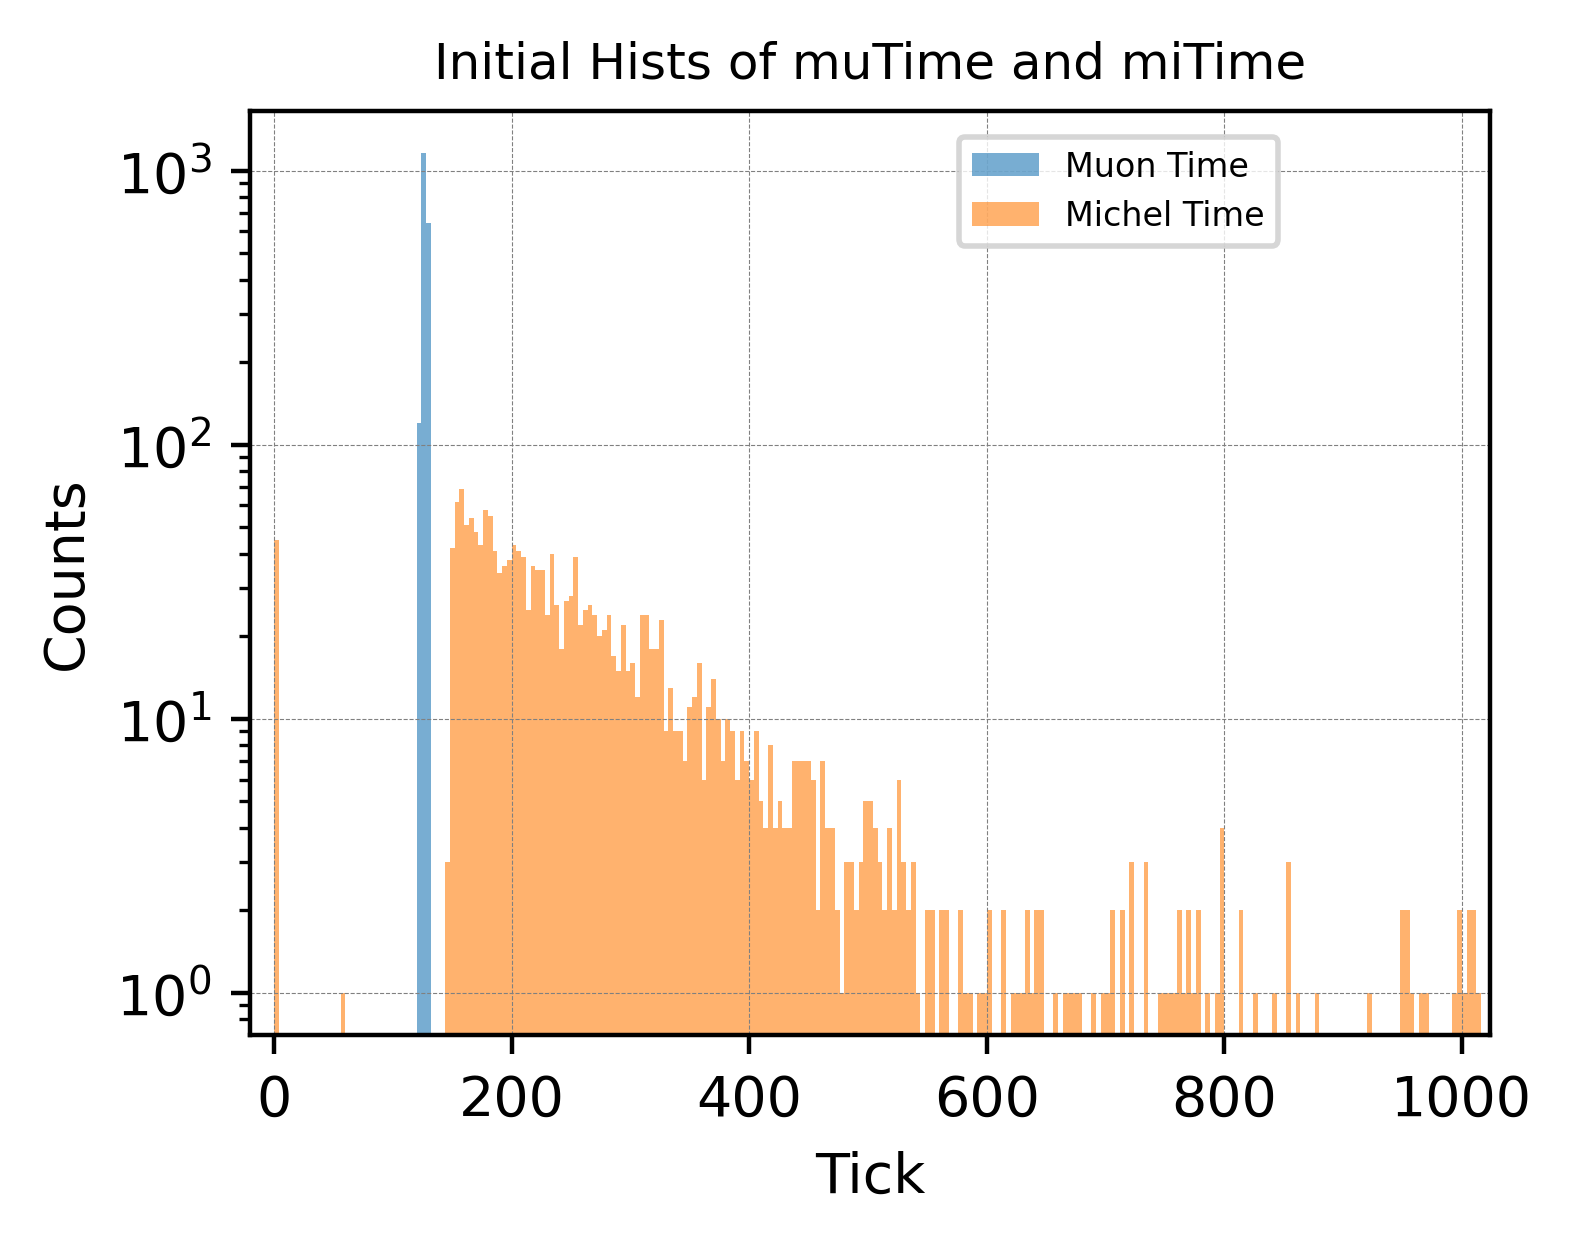




Lifetime distribution (Updated):
# Initial Candidates [-16000, 16000]:  1921


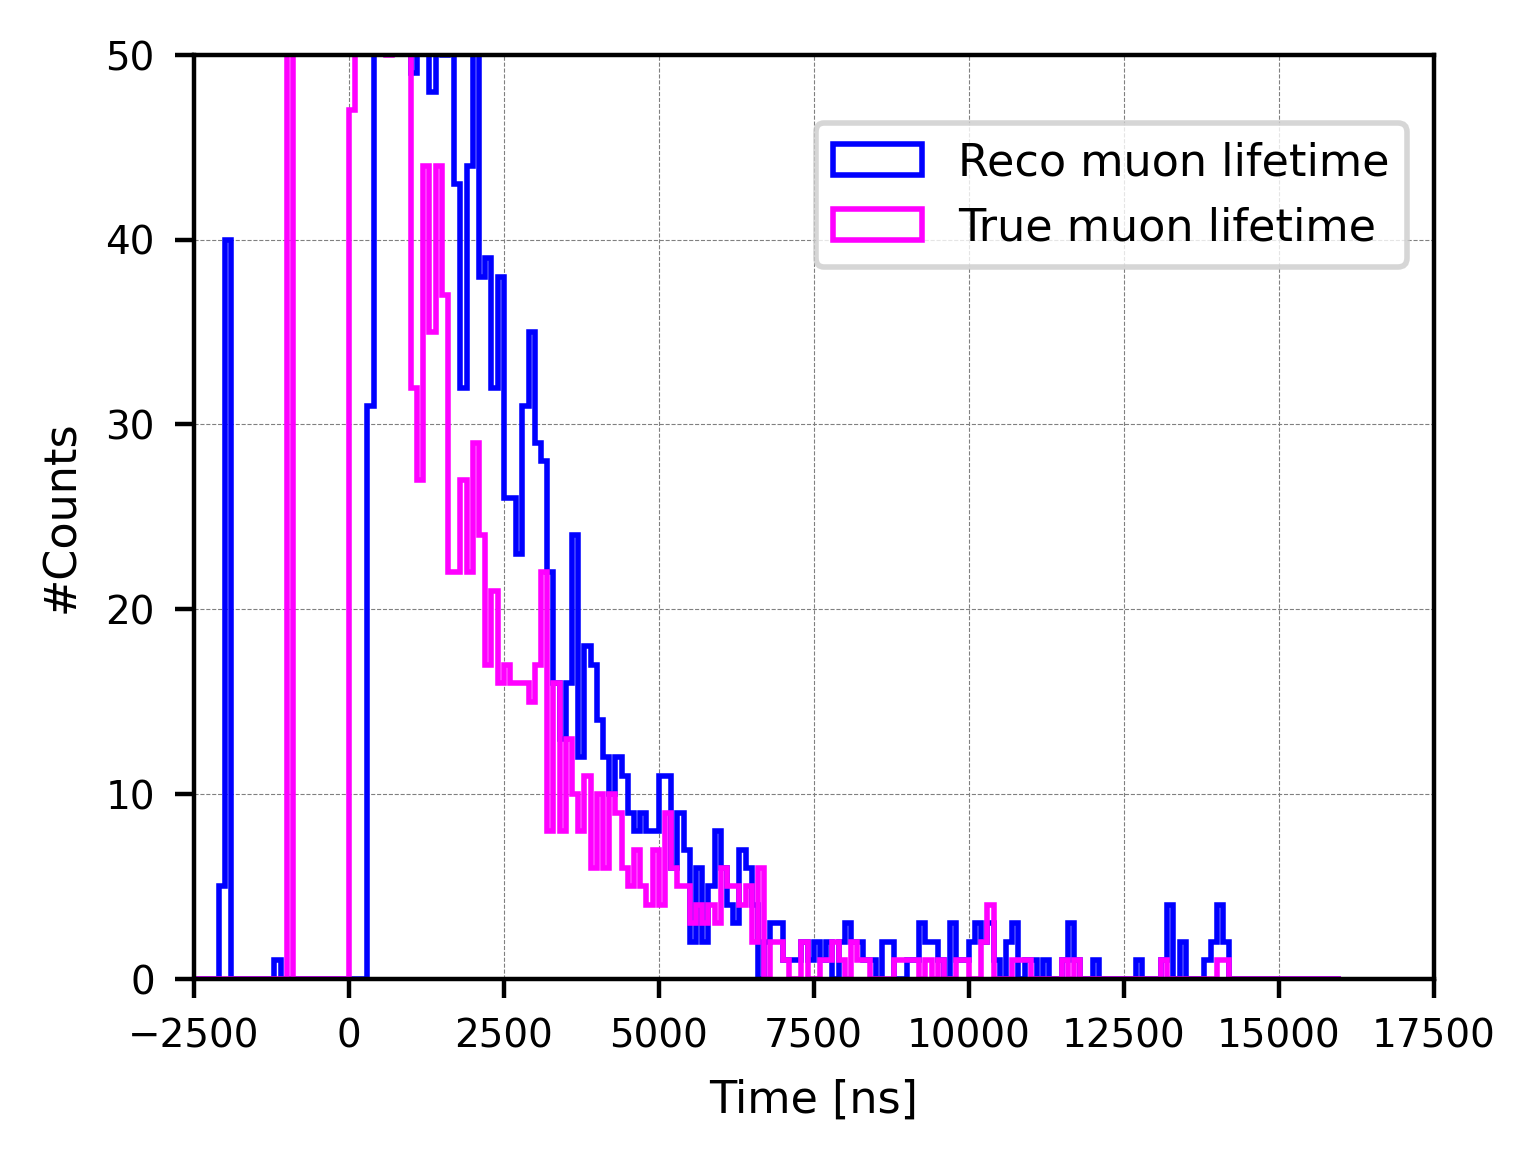

In [9]:
events_reco_update1 = []
events_true_update1 = []

lifetime_reco_update1 = []

for ev in events_reco_initial:
    muTime = ev.muon_time
    miTime = ev.michel_time
    energy = ev.energy

    if 120 <= muTime <= 130:
        events_reco_update1.append(ev)
        t = miTime-muTime
        lifetime_reco_update1.append(t)

        if energy > 0:
            events_true_update1.append(ev)


print("Muon events selection (mu peak constrained to [120, 130]):")
print("Updated Muon events: ", len(events_reco_update1), "/ ", len(events_reco_initial), 
       "({:.2f}%)".format(len(events_reco_update1)/len(events_reco_initial)*100))

# Element-wise subtraction: (mi - mu) for each corresponding element
print("Length of time_difference (Updated): ", len(lifetime_reco_update1))

print("\nMichel purity: ", len(events_true_update1), "/ ", len(events_reco_update1), 
      "({:.2f}%)".format(len(events_true_update1)/len(events_reco_update1)*100)) 









#Initial Mu and Michel time distributions=================================================
plt.figure(figsize=(4,3),dpi=400)

muTime_update = [ev.muon_time for ev in events_reco_update1]
miTime_update = [ev.michel_time for ev in events_reco_update1]


# Example: set your bin parameters
range_min_initial = 0
range_max_initial = 1024
bin_width_initial = 4  # You can change this value; default: 4
bins = np.arange(range_min_initial, range_max_initial + bin_width_initial, bin_width_initial)

# Plot histograms on the same canvas
plt.hist(muTime_update, bins=bins, alpha=0.6, label='Muon Time')
plt.hist(miTime_update, bins=bins, alpha=0.6, label='Michel Time')

plt.xlabel('Tick')
plt.ylabel('Counts')
plt.yscale('log')
plt.xlim(-20, 1024)
plt.title('Initial Hists of muTime and miTime', fontsize=9)

plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.99), fontsize=9, markerscale=4, ncol=1, prop={'size':6})
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()









# Muon Lifetime distribution (INITIAL; NO fitting)--------------------------------------------
plt.figure(figsize=(4, 3), dpi=400)

# Convert to ns (assuming mu_lifetime is already defined)
timdeDiff_update_ns = [value * 16 for value in lifetime_reco_update1]#reco lifetime---

lifetime_true_update1 = [ev.lifetime for ev in events_reco_update1]
lifetime_update_ns = [value * 1000 for value in lifetime_true_update1]#True lifetime---


print("\n\n\nLifetime distribution (Updated):")
print("# Initial Candidates [-16000, 16000]: ", len(timdeDiff_update_ns))

# Define histogram parameters
bin_width = 100
range_min = -16000
range_max = 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Plot histogram-----------------
plt.hist(timdeDiff_update_ns, bins=bins, range=(range_min, range_max),
         edgecolor='blue', histtype='step', linewidth=1.0,
         label='Reco muon lifetime')

plt.hist(lifetime_update_ns, bins=bins, range=(range_min, range_max),
         edgecolor='magenta', histtype='step', linewidth=1.0,
         label='True muon lifetime')


plt.xlim(-2500, 17500)
plt.ylim(0, 50)
#plt.yscale('log')
plt.xlabel('Time [ns]', fontsize=8)
plt.ylabel('#Counts', fontsize=8)
#plt.title('Purified (mu time [55, 65]) Lifetime')
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.74, 0.95), fontsize=11, markerscale=5, ncol=1, prop={'size':8})
plt.show()






<br />
<br />
<br />
<br />


### Purification / cut 3: remove events with unphysical lifetime (constrain lifetime to [500, inf))

#### (20251022): lifetime cut should be >0 here (we know later that 500 is NOT a good standard)




Lifetime distribution (Updated):
# Updated Candidates [0, 16000]:  1875

#Purity:  1414 / 1875 (75.41%)


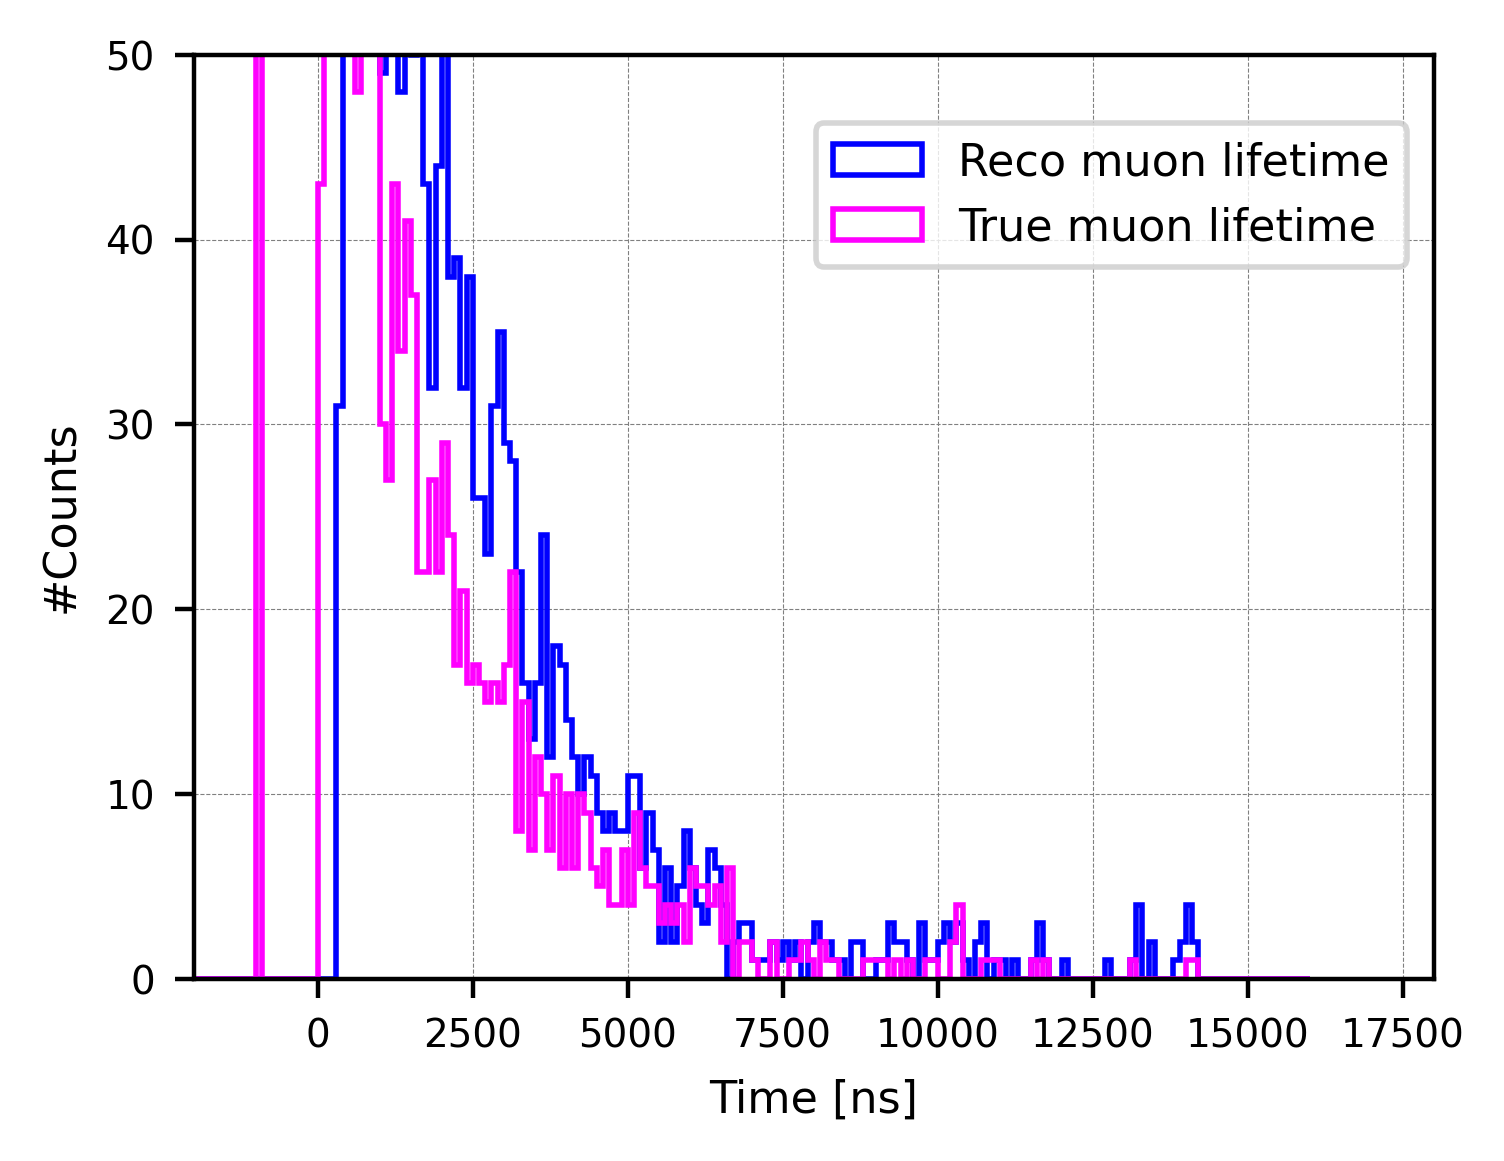

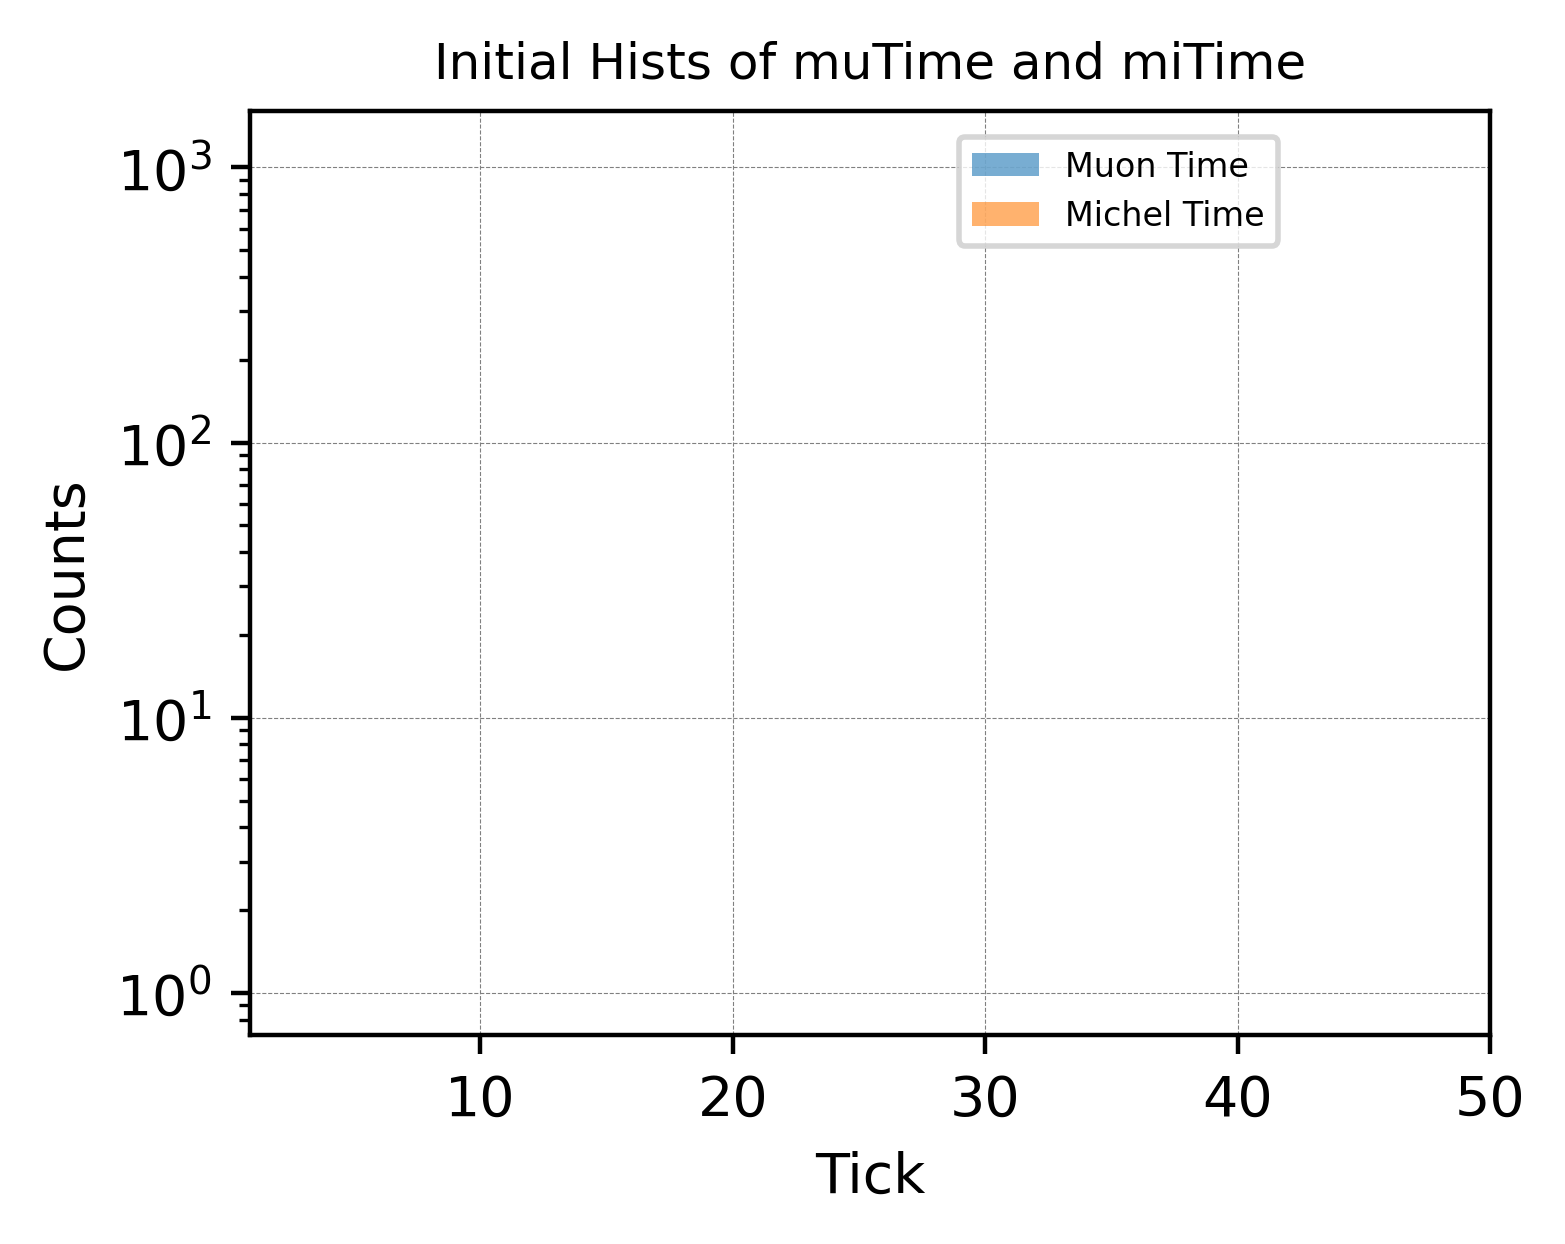


--------------------------------------
[-500, 500]:  861 / 1875 (45.92%)


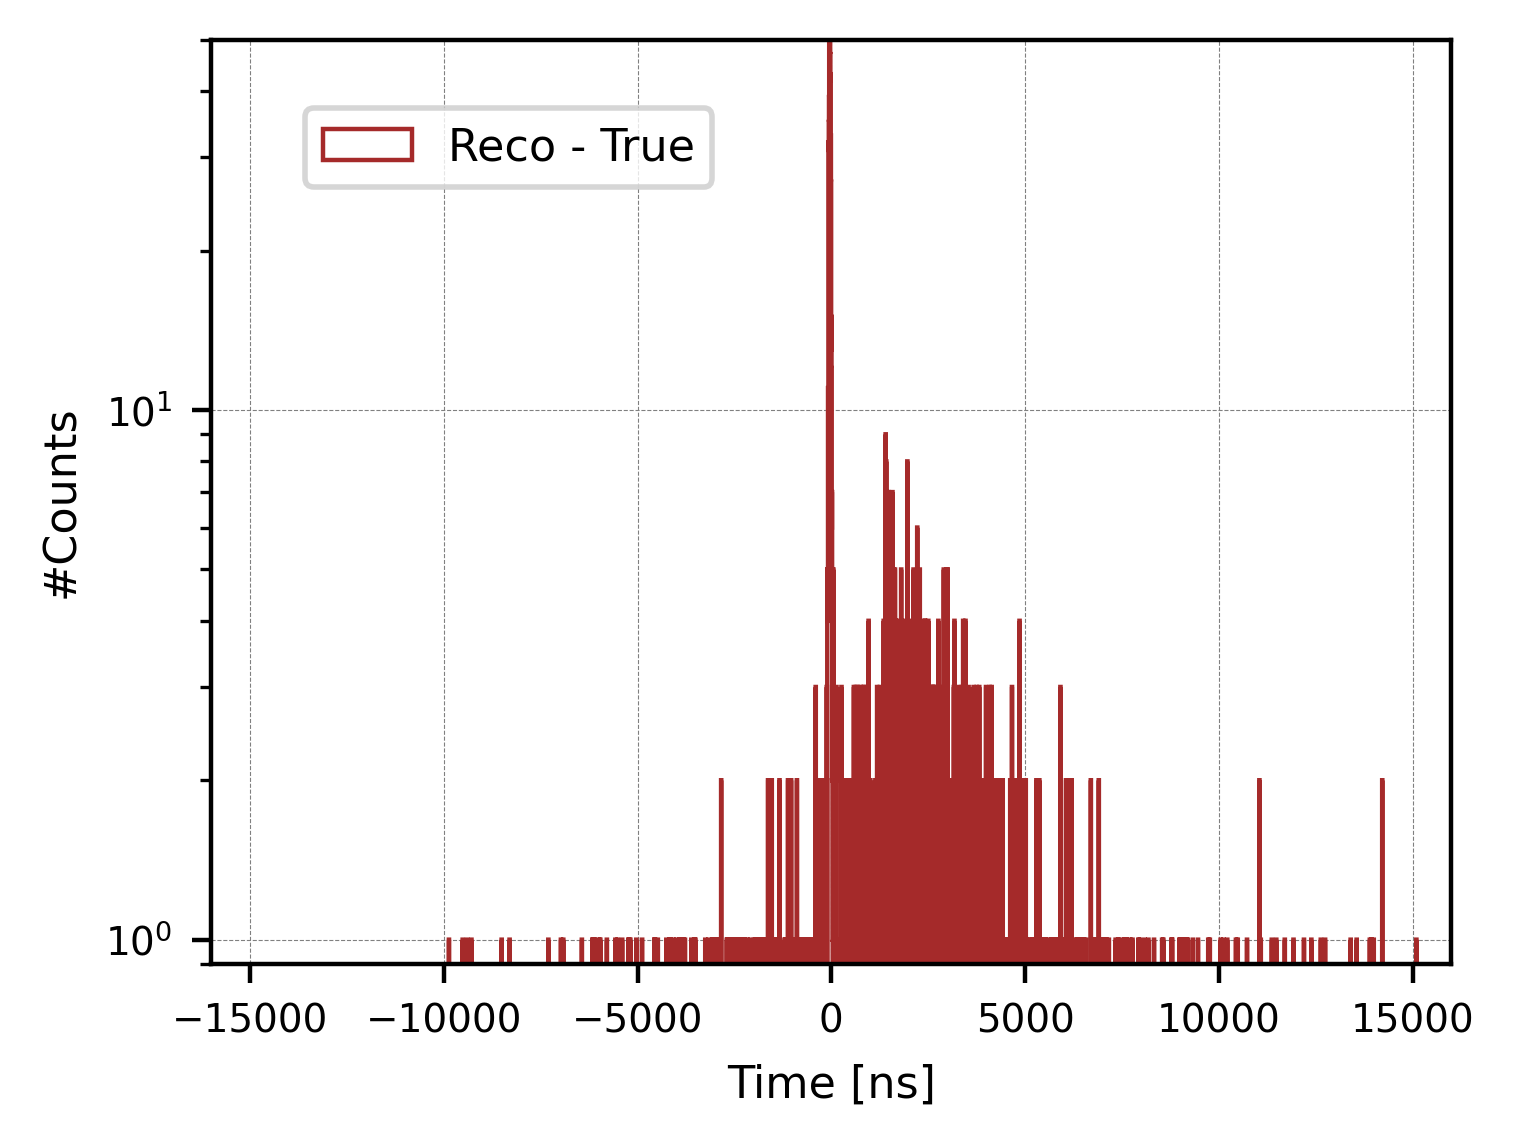



Explore the peak------


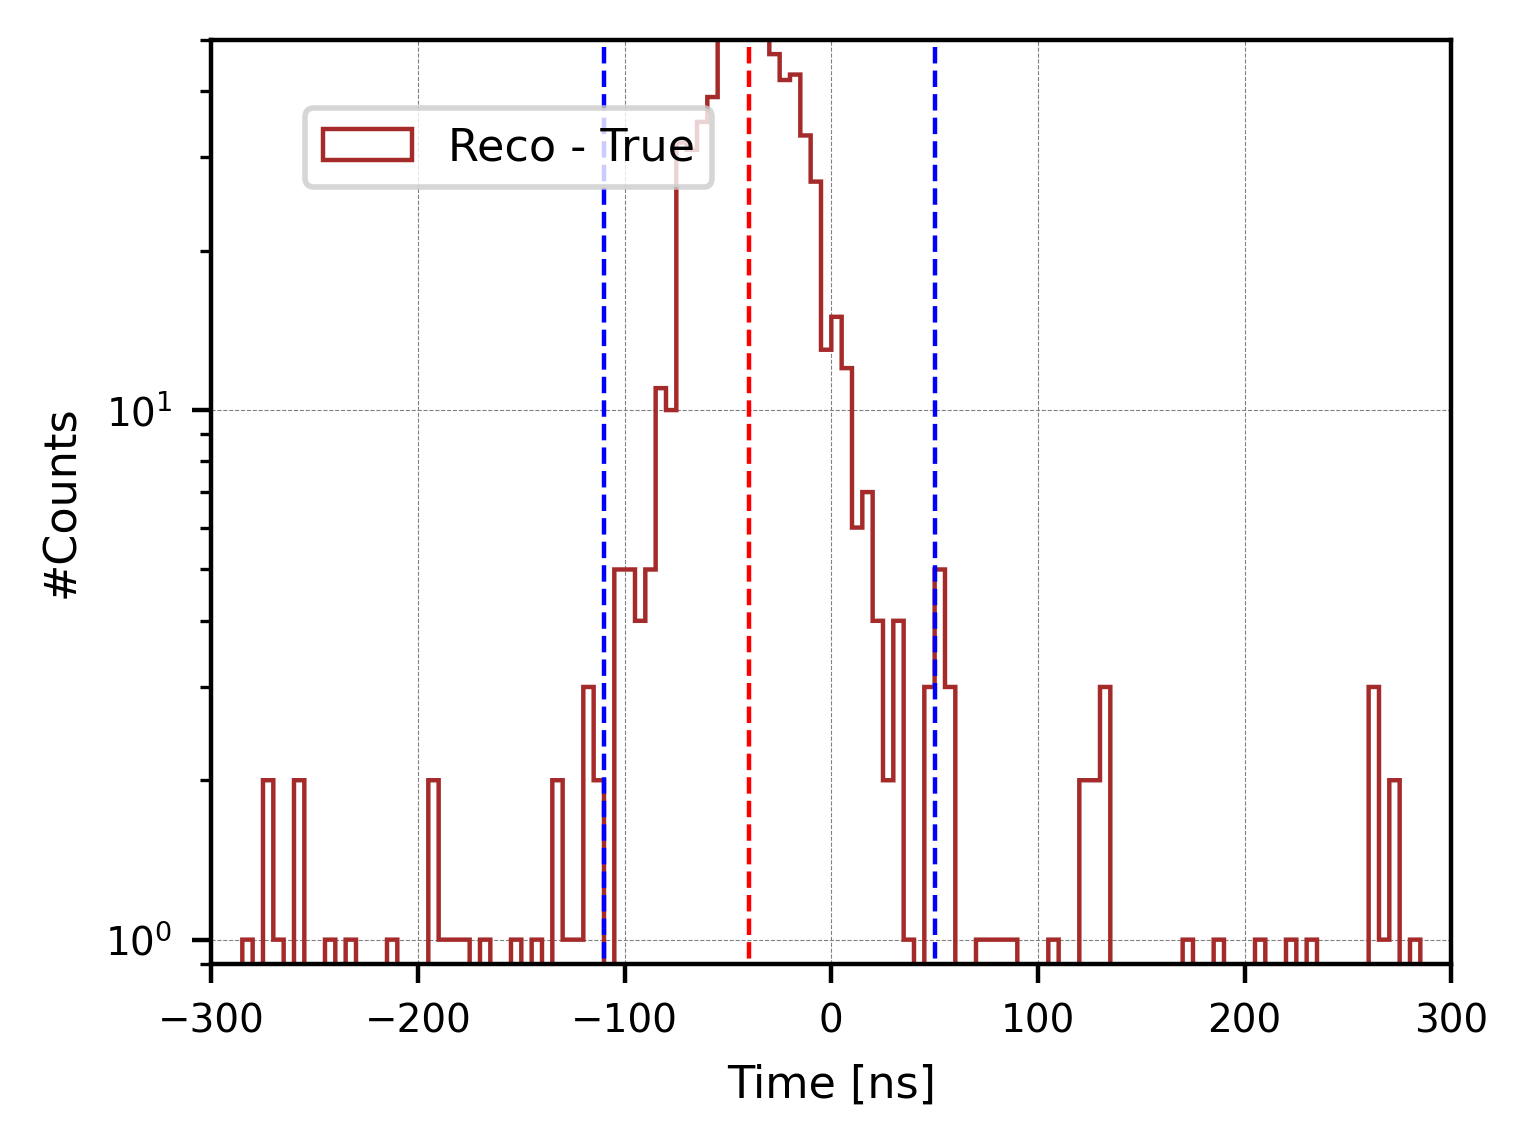



Do Gaussian Fitting for Peak!!!




In [10]:
events_reco_update2 = []#Dataset after Purification 2---
events_true_update2 = []
lifetime_reco_update2 = []

for ev in events_reco_update1:
    muTime = ev.muon_time
    miTime = ev.michel_time
    timeDiff = (miTime - muTime) * 16 #convert from tick to ns---
    e = ev.energy

    if 0 <= timeDiff: #keep physical events here---
        events_reco_update2.append(ev)
        lifetime_reco_update2.append(timeDiff)

        if e > 0:
            events_true_update2.append(ev)


print("\n\n\nLifetime distribution (Updated):")
print("# Updated Candidates [0, 16000]: ", len(events_reco_update2))

        
print("\n#Purity: ", len(events_true_update2), "/", len(events_reco_update2), 
     "({:.2f}%)".format(len(events_true_update2)/len(events_reco_update2)*100))







# Muon Lifetime distribution (INITIAL; NO fitting)--------------------------------------------
plt.figure(figsize=(4, 3), dpi=400)


# Define histogram parameters
bin_width = 100
range_min = -16000
range_max = 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Plot histogram-----------------
plt.hist(lifetime_reco_update2, bins=bins, range=(range_min, range_max),
         edgecolor='blue', histtype='step', linewidth=1.0,
         label='Reco muon lifetime')


lifetime_update_ns2 = [ev.lifetime * 1000 for ev in events_reco_update2]#True lifetime (contain false)---
plt.hist(lifetime_update_ns2, bins=bins, range=(range_min, range_max),
         edgecolor='magenta', histtype='step', linewidth=1.0,
         label='True muon lifetime')


plt.xlim(-2000, 18000)
plt.ylim(0, 50)
plt.xlabel('Time [ns]', fontsize=8)
plt.ylabel('#Counts', fontsize=8)
#plt.title('Purified (mu time [55, 65]) Lifetime')
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.74, 0.95), fontsize=11, markerscale=5, ncol=1, prop={'size':8})
plt.show()






#--------------------------------------------------------------
#Mu time & Mi time distribution after reco>0:
muTime_update_ns2 = [ev.muon_time for ev in events_reco_update2]
miTime_update_ns2 = [ev.michel_time for ev in events_reco_update2]

plt.figure(figsize=(4,3),dpi=400)

# Example: set your bin parameters
range_min_initial = 0
range_max_initial = 1024
bin_width_initial = 4  # You can change this value; default: 4
bins = np.arange(range_min_initial, range_max_initial + bin_width_initial, bin_width_initial)

# Plot histograms on the same canvas
plt.hist(muTime_update_ns2, bins=bins, alpha=0.6, label='Muon Time')
plt.hist(miTime_update_ns2, bins=bins, alpha=0.6, label='Michel Time')

plt.xlabel('Tick')
plt.ylabel('Counts')
plt.yscale('log')
plt.xlim(-20, 1024)
plt.xlim(0.9, 50)
plt.title('Initial Hists of muTime and miTime', fontsize=9)

plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.99), fontsize=9, markerscale=4, ncol=1, prop={'size':6})
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()












#---------------------------------------------------------------
#Reco True difference-------------------------------------------

diff_reco_true = []
for ev in events_reco_update2:
    muTime = ev.muon_time
    miTime = ev.michel_time
    timeDiff = (miTime - muTime) * 16 #convert from tick to ns---
    lifetime = ev.lifetime * 1000 #convert to ns---

    diff_reco_true.append(timeDiff-lifetime)


reco_true_count_500 = sum(-500 <= x <= 500 for x in diff_reco_true)
print("\n--------------------------------------")
print("[-500, 500]: ", reco_true_count_500, "/", len(diff_reco_true), 
     "({:.2f}%)".format(reco_true_count_500/len(diff_reco_true)*100))


#------------------------------------------
plt.figure(figsize=(4, 3), dpi=400)

# Define histogram parameters
bin_width = 5
range_min = -16000
range_max = 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Plot histogram-----------------
plt.hist(diff_reco_true, bins=bins, range=(range_min, range_max),
         edgecolor='brown', histtype='step', linewidth=0.8,
         label='Reco - True')


plt.xlim(-16000, 16000)
plt.ylim(0.9, 50)
plt.yscale('log')
plt.xlabel('Time [ns]', fontsize=8)
plt.ylabel('#Counts', fontsize=8)
#plt.title('Purified (mu time [55, 65]) Lifetime')
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.24, 0.95), fontsize=11, markerscale=5, ncol=1, prop={'size':8})
plt.show()





#------------------------------------------
plt.figure(figsize=(4, 3), dpi=400)

print("\n\nExplore the peak------")

# Plot histogram-----------------
plt.hist(diff_reco_true, bins=bins, range=(range_min, range_max),
         edgecolor='brown', histtype='step', linewidth=0.8,
         label='Reco - True')

plt.plot([-110, -110], [0, 10000], color="blue", linewidth=0.8, linestyle='--')
plt.plot([50, 50], [0, 10000], color="blue", linewidth=0.8, linestyle='--')
plt.plot([-40, -40], [0, 10000], color="red", linewidth=0.8, linestyle='--')

plt.xlim(-300, 300)
plt.ylim(0.9, 50)
plt.yscale('log')
plt.xlabel('Time [ns]', fontsize=8)
plt.ylabel('#Counts', fontsize=8)
#plt.title('Ex=')
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.24, 0.95), fontsize=11, markerscale=5, ncol=1, prop={'size':8})
plt.show()



print("\n\nDo Gaussian Fitting for Peak!!!\n\n")

<br />
<br />
<br />
<br />
<br />
<br />
<br />

## Explore Dataset After purification 3 [RecoT>0]:

In [11]:
@dataclass
class PdsEventNew: #new class containing reco lifetime, true lifetime & diff
    muon_time: Optional[int] = None
    michel_time: Optional[int] = None
    muon_intensity: Optional[float] = None
    michel_intensity: Optional[float] = None
    third_intensity: Optional[float] = None
    posX: Optional[float] = None
    posY: Optional[float] = None
    posZ: Optional[float] = None
    energy: Optional[float] = None
    lifetime: Optional[float] = None #in unit of us---
    pdg: Optional[int] = None
    eventID: Optional[int] = None
    trackID: Optional[int] = None
    date: Optional[int] = None 
    michel_score: Optional[float] = None         # ✅ NEW
    michel_hits: Optional[int] = None 
    reco_lifetime: Optional[float] = None
    true_lifetime: Optional[float] = None # in unit of ns---
    diff_lifetime: Optional[float] = None
    michel_rise: Optional[float] = None
    michel_drop: Optional[float] = None



#Test print---------------
print("Size of events_reco_update2 (previous class): ", len(events_reco_update2))

#New calculated reco & true lifetime lists:
recoLife_update2 = []
trueLife_update2 = []  
diffLife_update2 = []

michel_rise_slope = []
michel_drop_slope = []

for ev in events_reco_update2:
    muTime = ev.muon_time
    miTime = ev.michel_time
    timeDiff = (miTime - muTime) * 16 #convert from tick to ns---

    recoLife_update2.append(timeDiff)
    trueLife_update2.append(ev.lifetime * 1000)
    diffLife_update2.append(timeDiff - ev.lifetime * 1000)

    left_slope = ev.mi_leftHeight / (miTime - ev.mi_leftTurn)
    right_slope = ev.mi_rightHeight / (ev.mi_rightTurn - miTime)

#    left_slope = (miTime - ev.mi_leftTurn)
#    right_slope = (ev.mi_rightTurn - miTime)

    michel_rise_slope.append(left_slope)
    michel_drop_slope.append(right_slope)

print("Size of lifetime_reco_update2               : ", len(recoLife_update2))
print("Size of lifetime_update_ns2                 : ", len(trueLife_update2))



#Final events with new features----------
events_newClass = []
for ev, reco_life, true_life, diff_life, rise, drop in zip(
    events_reco_update2, 
    recoLife_update2, 
    trueLife_update2, 
    diffLife_update2,
    michel_rise_slope,
    michel_drop_slope
    ):
    new_ev = PdsEventNew(
        muon_time=ev.muon_time,
        michel_time=ev.michel_time,
        muon_intensity=ev.muon_intensity,
        michel_intensity=ev.michel_intensity,
        third_intensity=ev.third_intensity,
        posX=ev.posX,
        posY=ev.posY,
        posZ=ev.posZ,
        energy=ev.energy,
        lifetime=ev.lifetime,
        pdg=ev.pdg,
        eventID=ev.eventID,
        trackID=ev.trackID,
        date=ev.date,
        michel_score=ev.michel_score,
        michel_hits=ev.michel_hits, 
        reco_lifetime=reco_life,
        true_lifetime=true_life,
        diff_lifetime=diff_life,
        michel_rise=rise,
        michel_drop=drop
    )
    events_newClass.append(new_ev)

print("\nLength of final dataset in format of new class: ", len(events_newClass))


events_diff500 = []
events_diff0 = []
true_newClass = []
for ev in events_newClass:
    if ev.energy > 0:
        true_newClass.append(ev)

#===========================================================================
    if ev.diff_lifetime > 50 or ev.diff_lifetime < -110:
        events_diff500.append(ev)
    if -110 < ev.diff_lifetime < 50:
        events_diff0.append(ev)
#===========================================================================

print("\nLength of final true in format of new class: ", len(true_newClass))

print("\nEvents with diff [-110, 50] : ", len(events_diff0), "/", len(true_newClass),
       "({:.2f}%)".format(len(events_diff0)/len(true_newClass)*100))
print("\nEvents with diff OTHERS: ", len(events_diff500), "/", len(events_newClass),
       "({:.2f}%)".format(len(events_diff500)/len(events_newClass)*100))


Size of events_reco_update2 (previous class):  1875
Size of lifetime_reco_update2               :  1875
Size of lifetime_update_ns2                 :  1875

Length of final dataset in format of new class:  1875

Length of final true in format of new class:  1414

Events with diff [-110, 50] :  756 / 1414 (53.47%)

Events with diff OTHERS:  1119 / 1875 (59.68%)


<br />

#### Single Event Inspection:

In [12]:
# False Michels-----------
print("Michel-like FALSE Events:===================")
for ev in events_newClass:
    if ev.energy > 0 and ev.muon_intensity < 100 and ev.third_intensity > 1.0 and -110 < ev.diff_lifetime < 50:
        print(ev)





# "Background"
print("\n\n=======================================")
#for i, ev in enumerate(true_newClass[:100]):
#    print(f"Event {i}: {ev}")



Michel-like FALSE Events:===================
PdsEventNew(muon_time=129, michel_time=222, muon_intensity=89.1636, michel_intensity=15.0287, third_intensity=1.08377, posX=324.213, posY=429.612, posZ=314.881, energy=40.8405, lifetime=1.50798, pdg=-11, eventID=1044, trackID=22, date=20251101, michel_score=0.418787, michel_hits=13, reco_lifetime=1488, true_lifetime=1507.98, diff_lifetime=-19.980000000000018, michel_rise=1.0019133333333334, michel_drop=0.6182538461538462)
PdsEventNew(muon_time=127, michel_time=441, muon_intensity=22.8624, michel_intensity=3.46138, third_intensity=1.80181, posX=-177.694, posY=269.018, posZ=246.653, energy=29.6923, lifetime=5.04239, pdg=-11, eventID=1181, trackID=6, date=20251101, michel_score=0.514605, michel_hits=6, reco_lifetime=5024, true_lifetime=5042.39, diff_lifetime=-18.390000000000327, michel_rise=0.173069, michel_drop=0.19876052631578947)
PdsEventNew(muon_time=127, michel_time=451, muon_intensity=21.2123, michel_intensity=4.25107, third_intensity=1.2